# **ICM406 Programming for Finance Individual Report**

*Programme:* MSc Finance & FinTech, Henley Business School, University of Reading  
*Module:* ICM406 Programming for Finance  
*Student:* Salvy Bin Tareq \
*Notebook:* Data engineering, feature construction, econometrics, and reproducible outputs.

##### *Project Design: ESG Scores and Downside Risk During Market Turmoil*

#### **Research Question**

***Do higher ESG-rated firms suffer smaller peak-to-trough drawdowns during market stress events (the 2020 COVID-19 crash and the 2022 inflation downturn), and is this relationship robust after controlling for firm characteristics such as size and leverage?***

In [1]:
#all the Packages are installed and ensured

import sys, platform
import pandas as pd
import numpy as np
import yfinance as yf
import sqlite3
import statsmodels.api as sm
from tqdm import tqdm

print("Python:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("yfinance:", yf.__version__)
print("statsmodels:", sm.__version__)


Python: 3.11.7 | packaged by Anaconda, Inc. | (main, Dec 15 2023, 18:05:47) [MSC v.1916 64 bit (AMD64)]
pandas: 2.2.2
numpy: 1.26.4
yfinance: 0.2.66
statsmodels: 0.14.2


In [2]:
# Standard Configuration parameter
START_DATE = "2020-01-01"
END_DATE   = "2025-01-01"   # 5 years window
DB_PATH    = "./esg_project.db"
DATA_DIR   = "./data_cache"

CRISIS_WINDOWS = {
    "COVID_CRASH": ("2020-02-19", "2020-03-23"),
    "INFLATION_2022": ("2022-04-01", "2022-06-30")
}

print("START_DATE:", START_DATE)
print("END_DATE:", END_DATE)
print("DB_PATH:", DB_PATH)
print("CRISIS_WINDOWS:", CRISIS_WINDOWS)

START_DATE: 2020-01-01
END_DATE: 2025-01-01
DB_PATH: ./esg_project.db
CRISIS_WINDOWS: {'COVID_CRASH': ('2020-02-19', '2020-03-23'), 'INFLATION_2022': ('2022-04-01', '2022-06-30')}


In [40]:
import os
import time
import random
import pandas as pd
import yfinance as yf

base = r"E:\UNIVERSITY OF READING\ICM 406\Python Projects"
os.makedirs(base, exist_ok=True)

out_prices = os.path.join(base, "prices_long.csv")
out_tickers = os.path.join(base, "tickers_universe.csv")
# ticker list

tickers = [
 'MSFT','AAPL','GOOG','AMZN','NVDA','META','TSLA','IBM','ORCL','SAP',
 'INTU','NOW','ADBE','CRM','CSCO','QCOM','TXN','AVGO','AMD','INTC',
 'MU','LRCX','ASML','KLAC','NXPI','MRVL','ADI','ON','MCHP','TER',
 'JNJ','PFE','MRK','BMY','LLY','ABT','MDT','SYK','TMO','DHR',
 'GILD','REGN','VRTX','ZTS','ISRG','BIIB','AMGN','BSX','HUM','CI',
'JPM','BAC','GS','MS','C','WFC','USB','PNC','TFC','COF',
 'AXP','SCHW','BLK','BX','KKR','AIG','PRU','MET','ALL','TRV',
 'KO','PEP','PG','CL','KMB','CHD','MDLZ','KHC','GIS','HSY',
 'MCD','SBUX','YUM','DPZ','CMG','COST','WMT','TGT','KR','DG',
 'XOM','CVX','COP','EOG','SLB','HAL','OXY','MPC','PSX','VLO',
 'NEE','DUK','SO','D','EXC','AEP','XEL','ED','EIX','PCG',
 'CAT','DE','ETN','EMR','HON','GE','MMM','ITW','ROK','PH',
 'CMI','DOV','XYL','AME','FAST','GWW','URI','JCI','IR','VMC',
 'FDX','UPS','DAL','UAL','LUV','AAL','CSX','NSC','UNP','CP',
 'GM','F','TSLA','RIVN','LCID','NIO','STLA','TM','HMC',
 'DIS','NFLX','PARA','WBD','FOX','NWS','EA','TTWO','ROBLX','UBER',
 'LYFT','ABNB','BKNG','EXPE','MAR','HLT','H','WYNN','MGM','LVS',
 'V','MA','PYPL','SQ','AFRM','SHOP','SE','MELI','JD','BABA',
 'PDD','TCOM','NTES','BIDU','SONY','NTDOY','RBLX','COIN','HOOD',
 'PLTR','SNOW','DDOG','ZS','CRWD','OKTA','PANW','FTNT','NET','MDB',
  'AOS','MKC','NUE','MAS','PAYC','WRB'
]



tickers = (
    pd.Series(tickers, dtype="string")
      .str.strip().str.upper()
      .str.replace(".", "-", regex=False)
      .dropna().drop_duplicates().sort_values()
      .tolist()
)

pd.DataFrame({"ticker": tickers}).to_csv(out_tickers, index=False)
print("Tickers saved:", out_tickers, "| count:", len(tickers))


start = "2020-01-01"
end   = "2024-12-31"
chunk_size = 25  
pause_seconds = (1.0, 2.5)  

frames = []


for i in range(0, len(tickers), chunk_size):
    batch = tickers[i:i+chunk_size]
    print(f"Downloading {i+1}-{min(i+chunk_size, len(tickers))} / {len(tickers)} ...")

    wide = yf.download(
        tickers=batch,
        start=start,
        end=end,
        interval="1d",
        group_by="ticker",
        auto_adjust=False,
        actions=False,
        threads=True,
        progress=False
    )

    if wide is None or wide.empty:
        print("  -> empty batch, skipping")
        continue

   
    if isinstance(wide.columns, pd.MultiIndex):
        
        lvl0 = set(map(str, wide.columns.get_level_values(0)))
        ohlcv = {"Open","High","Low","Close","Adj Close","Volume"}
        if len(ohlcv & lvl0) >= 3:
            wide = wide.swaplevel(0, 1, axis=1)

        
        long = (
            wide.stack(0)  
                .reset_index()
                .rename(columns={"level_1": "Ticker"})
        )
        long = long.rename(columns={"Date": "Date"})  # just in case

    else:
        
        t = batch[0]
        long = wide.reset_index()
        long["Ticker"] = t

    
    long.columns = [str(c).strip() for c in long.columns]
    if "Adj Close" not in long.columns and "AdjClose" in long.columns:
        long = long.rename(columns={"AdjClose": "Adj Close"})

    keep = ["Date","Ticker","Adj Close","Close","High","Low","Open","Volume"]
    long = long[[c for c in keep if c in long.columns]].copy()

    long["Date"] = pd.to_datetime(long["Date"], errors="coerce")
    long["Ticker"] = long["Ticker"].astype(str).str.strip().str.upper().str.replace(".", "-", regex=False)

    frames.append(long)

    time.sleep(random.uniform(*pause_seconds))

prices_long = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

prices_long = prices_long.dropna(subset=["Date","Ticker"])
prices_long = prices_long.drop_duplicates(subset=["Date","Ticker"]).sort_values(["Ticker","Date"])

prices_long.to_csv(out_prices, index=False)

print("\nSaved daily prices to:", out_prices)
print("Rows:", len(prices_long), "| Unique tickers:", prices_long["Ticker"].nunique())
print("Date range:", prices_long["Date"].min(), "to", prices_long["Date"].max())
prices_long.head()

Tickers saved: E:\UNIVERSITY OF READING\ICM 406\Python Projects\tickers_universe.csv | count: 203


C:\Users\Salvy Bin Tareq\AppData\Local\Temp\ipykernel_26636\1010291825.py:103: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  wide.stack(0)  # stack ticker level


C:\Users\Salvy Bin Tareq\AppData\Local\Temp\ipykernel_26636\1010291825.py:103: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  wide.stack(0)  # stack ticker level


C:\Users\Salvy Bin Tareq\AppData\Local\Temp\ipykernel_26636\1010291825.py:103: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  wide.stack(0)  # stack ticker level


C:\Users\Salvy Bin Tareq\AppData\Local\Temp\ipykernel_26636\1010291825.py:103: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  wide.stack(0)  # stack ticker level


...


2 Failed downloads:
['SQ', 'ROBLX']: YFTzMissingError('possibly delisted; no timezone found')
C:\Users\Salvy Bin Tareq\AppData\Local\Temp\ipykernel_26636\1010291825.py:103: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  wide.stack(0)  # stack ticker level


C:\Users\Salvy Bin Tareq\AppData\Local\Temp\ipykernel_26636\1010291825.py:103: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  wide.stack(0)  # stack ticker level


C:\Users\Salvy Bin Tareq\AppData\Local\Temp\ipykernel_26636\1010291825.py:103: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  wide.stack(0)  # stack ticker level



Saved daily prices to: E:\UNIVERSITY OF READING\ICM 406\Python Projects\prices_long.csv
Rows: 248871 | Unique tickers: 200
Date range: 2020-01-02 00:00:00 to 2024-12-30 00:00:00


,Date,Ticker,Adj Close,Close,High,Low,Open,Volume
0,2020-01-02,AAL,28.982893,29.090000,29.299999,28.650000,28.980000,6451100.0
23,2020-01-03,AAL,27.548195,27.650000,28.290001,27.340000,28.270000,14008900.0
46,2020-01-06,AAL,27.219410,27.320000,27.490000,27.080000,27.190001,6105800.0
69,2020-01-07,AAL,27.119778,27.219999,27.680000,27.059999,27.559999,6105900.0
92,2020-01-08,AAL,27.737495,27.840000,28.090000,27.070000,27.100000,10496800.0


In [41]:

def download_prices(ticker, start=START_DATE, end=END_DATE):
    df = yf.download(ticker, start=start, end=end, auto_adjust=False, progress=False)
    if df is None or df.empty:
        return None
    df = df.reset_index()
    df["Ticker"] = ticker
    return df

def get_esg_scores(ticker):
    try:
        t = yf.Ticker(ticker)
        s = t.sustainability  
        if s is None or len(s)==0:
            return None
        col = s.columns[0]
        out = {
            "Ticker": ticker,
            "ESG_Total": float(s.loc["totalEsg", col]) if "totalEsg" in s.index else np.nan,
            "ESG_E": float(s.loc["environmentScore", col]) if "environmentScore" in s.index else np.nan,
            "ESG_S": float(s.loc["socialScore", col]) if "socialScore" in s.index else np.nan,
            "ESG_G": float(s.loc["governanceScore", col]) if "governanceScore" in s.index else np.nan,
        }
        return out
    except Exception:
        return None

def get_controls_from_info(ticker):
    try:
        info = yf.Ticker(ticker).info
        out = {
            "Ticker": ticker,
            "MarketCap": info.get("marketCap", np.nan),
            "TotalDebt": info.get("totalDebt", np.nan),
            "TotalCash": info.get("totalCash", np.nan),
                "DebtToEquity": info.get("debtToEquity", np.nan)
        }
        return out
    except Exception:
        return {"Ticker": ticker, "MarketCap": np.nan, "TotalDebt": np.nan, "TotalCash": np.nan, "DebtToEquity": np.nan}

def max_drawdown(price_series):
    roll_max = price_series.cummax()
    dd = (price_series / roll_max) - 1.0
    return dd.min()

In [42]:
# downloading the daily prices of 200+ frims
price_frames = []
failed = []

for tk in tqdm(tickers):
    df = download_prices(tk)
    if df is None:
        failed.append(tk)
        continue
    price_frames.append(df)

prices = pd.concat(price_frames, ignore_index=True)
print("Downloaded tickers:", prices["Ticker"].nunique())
print("Failed tickers:", len(failed))
prices.head()


 69%|██████▉   | 141/203 [00:22<00:08,  7.22it/s]
1 Failed download:
['PARA']: YFTzMissingError('possibly delisted; no timezone found')
 77%|███████▋  | 157/203 [00:25<00:05,  8.33it/s]
1 Failed download:
['ROBLX']: YFTzMissingError('possibly delisted; no timezone found')
 83%|████████▎ | 169/203 [00:26<00:05,  5.94it/s]
1 Failed download:
['SQ']: YFTzMissingError('possibly delisted; no timezone found')
100%|██████████| 203/203 [00:32<00:00,  6.30it/s]


Downloaded tickers: 200
Failed tickers: 3


Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,Adj Close,Close,...,High,Low,Open,Volume,Adj Close,Close,High,Low,Open,Volume
Ticker,,AAL,AAL,AAL,AAL,AAL,AAL,,AAPL,AAPL,...,ZS,ZS,ZS,ZS,ZTS,ZTS,ZTS,ZTS,ZTS,ZTS
0,2020-01-02,28.982893,29.090000,29.299999,28.650000,28.980000,6451100.0,AAL,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-03,27.548195,27.650000,28.290001,27.340000,28.270000,14008900.0,AAL,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-06,27.219410,27.320000,27.490000,27.080000,27.190001,6105800.0,AAL,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-07,27.119778,27.219999,27.680000,27.059999,27.559999,6105900.0,AAL,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-08,27.737495,27.840000,28.090000,27.070000,27.100000,10496800.0,AAL,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
# summary of the statistics for the numerical data set
# Informations include count, mean, standard deviation, minimum, maximum, and quartile values.
df.describe()


Price,Date,Adj Close,Close,High,Low,Open,Volume
Ticker,,ZTS,ZTS,ZTS,ZTS,ZTS,ZTS
count,1258,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,2022-07-01 15:39:46.645468928,165.927163,171.532925,173.425906,169.672385,171.556351,2.077618e+06
min,2020-01-02 00:00:00,88.210541,92.660004,101.040001,90.139999,98.709999,4.174000e+05
25%,2021-04-02 00:00:00,152.413902,158.645004,160.462505,157.212505,158.669998,1.442100e+06
50%,2022-06-30 12:00:00,166.001610,170.879997,172.489998,169.195000,170.875000,1.840400e+06
75%,2023-10-01 06:00:00,181.120369,186.522503,188.522499,184.664993,186.419998,2.432225e+06
max,2024-12-31 00:00:00,237.474976,247.029999,249.270004,244.960007,247.050003,1.157780e+07
std,NaN,22.663890,22.926909,22.903494,22.931919,22.977779,9.989638e+05


In [44]:
# Cheking Missing values
import pandas as pd
import os

base = r"E:\UNIVERSITY OF READING\ICM 406\Python Projects"
path = os.path.join(base, "prices_long.csv")

prices_long = pd.read_csv(path)
prices_long.columns = prices_long.columns.astype(str).str.strip()

# Standardise key columns
if "date" in prices_long.columns and "Date" not in prices_long.columns:
    prices_long = prices_long.rename(columns={"date": "Date"})
if "ticker" in prices_long.columns and "Ticker" not in prices_long.columns:
    prices_long = prices_long.rename(columns={"ticker": "Ticker"})

prices_long["Date"] = pd.to_datetime(prices_long["Date"], errors="coerce", dayfirst=True)
prices_long = prices_long.dropna(subset=["Date"])

prices_long["Ticker"] = (
    prices_long["Ticker"].astype(str).str.strip().str.upper().str.replace(".", "-", regex=False)
)

print("Date range:", prices_long["Date"].min(), "to", prices_long["Date"].max())
print("Duplicate (Ticker,Date) rows:", prices_long.duplicated(["Ticker", "Date"]).sum())
print("Missing values per column:\n", prices_long.isnull().sum())
print("Unique tickers:", prices_long["Ticker"].nunique())

Date range: 2020-01-04 00:00:00 to 2024-12-12 00:00:00
Duplicate (Ticker,Date) rows: 0
Missing values per column:
 Date         0
Ticker       0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
Unique tickers: 200


In [45]:
#SQL lite : Storing Raw Data Prices
conn = sqlite3.connect(DB_PATH)

prices.to_sql("prices_raw", conn, if_exists="replace", index=False)

cur = conn.cursor()
cur.execute("SELECT COUNT(*) FROM prices_raw;")
print("rows(prices_raw):", cur.fetchone()[0])


rows(prices_raw): 249071


In [11]:
import sys
!{sys.executable} -m pip install yesg

In [46]:
# DOWNLOAD CONTROLS (SIZE/LEVERAGE PROXIES)
controls_list = []
for tk in tqdm(prices["Ticker"].unique()):
    controls_list.append(get_controls_from_info(tk))

controls = pd.DataFrame(controls_list)

print(controls.isnull().mean().sort_values())
controls.head()

base = r"E:\UNIVERSITY OF READING\ICM 406\Python Projects"
out_path = os.path.join(base, "controls_raw.csv")

controls.to_csv(out_path, index=False)

print("Saved controls CSV to:", out_path)


100%|██████████| 200/200 [01:03<00:00,  3.13it/s]

Ticker          0.000
MarketCap       0.000
TotalDebt       0.010
TotalCash       0.010
DebtToEquity    0.105
dtype: float64
Saved controls CSV to: E:\UNIVERSITY OF READING\ICM 406\Python Projects\controls_raw.csv


In [48]:
import os
import pandas as pd

base = r"E:\UNIVERSITY OF READING\ICM 406\Python Projects"
esg_out = os.path.join(base, "esg_raw.csv")

esg = pd.DataFrame(esg_rows)
saved_esg = safe_to_csv(esg, esg_out, index=False)

print("Saved ESG CSV to:", saved_esg)


Saved: E:\UNIVERSITY OF READING\ICM 406\Python Projects\esg_raw.csv
Saved ESG CSV to: E:\UNIVERSITY OF READING\ICM 406\Python Projects\esg_raw.csv


In [50]:
# DOWNLOAD CONTROLS (SIZE/LEVERAGE PROXIES)

controls_list = []
for tk in tqdm(prices["Ticker"].unique()):
    controls_list.append(get_controls_from_info(tk))

controls = pd.DataFrame(controls_list)

print(controls.isnull().mean().sort_values())
controls.head()

base = r"E:\UNIVERSITY OF READING\ICM 406\Python Projects"
out_path = os.path.join(base, "controls_raw.csv")

controls.to_csv(out_path, index=False)

print("Saved controls CSV to:", out_path)


100%|██████████| 200/200 [01:04<00:00,  3.11it/s]

Ticker          0.000
MarketCap       0.000
TotalDebt       0.010
TotalCash       0.010
DebtToEquity    0.105
dtype: float64
Saved controls CSV to: E:\UNIVERSITY OF READING\ICM 406\Python Projects\controls_raw.csv


In [51]:
import os
import time
import random
import numpy as np
import pandas as pd
import requests
import yfinance as yf
import sqlite3
from datetime import datetime
from pandas.errors import EmptyDataError

base = r"E:\UNIVERSITY OF READING\ICM 406\Python Projects"
os.makedirs(base, exist_ok=True)

tickers_path = os.path.join(base, "tickers_universe.csv")
controls_out = os.path.join(base, "controls_raw.csv")
esg_out      = os.path.join(base, "esg_raw.csv")
missing_out  = os.path.join(base, "esg_missing.csv")
errors_out   = os.path.join(base, "esg_errors.csv")
DB_PATH      = os.path.join(base, "icm406.db")

def safe_to_csv(df, path, index=False):
    try:
        df.to_csv(path, index=index)
        print("Saved:", path)
        return path
    except PermissionError:
        folder = os.path.dirname(path)
        base_name = os.path.splitext(os.path.basename(path))[0]
        ts = datetime.now().strftime("%Y%m%d_%H%M%S")
        new_path = os.path.join(folder, f"{base_name}_{ts}.csv")
        df.to_csv(new_path, index=index)
        print("File locked. Saved instead to:", new_path)
        return new_path

def safe_read_csv(path):
    if not os.path.exists(path):
        return None
    try:
        df = pd.read_csv(path)
        if df.shape[1] == 0:
            return None
        return df
    except EmptyDataError:
        return None

print("Working folder:", base)


Working folder: E:\UNIVERSITY OF READING\ICM 406\Python Projects


In [52]:
tickers_df = pd.read_csv(tickers_path)
tickers = tickers_df.iloc[:, 0].astype(str).str.strip().tolist()
print("Tickers loaded:", len(tickers))
print("First 10:", tickers[:10])


Tickers loaded: 203
First 10: ['AAL', 'AAPL', 'ABNB', 'ABT', 'ADBE', 'ADI', 'AEP', 'AFRM', 'AIG', 'ALL']


In [53]:
def get_controls_from_info(tk):
    info = yf.Ticker(tk).info
    return {
        "Ticker": tk,
        "MarketCap": info.get("marketCap", np.nan),
        "TotalDebt": info.get("totalDebt", np.nan),
        "TotalCash": info.get("totalCash", np.nan),
        "DebtToEquity": info.get("debtToEquity", np.nan),
    }

controls_list = []
controls_errors = []

for tk in tickers:
    try:
        controls_list.append(get_controls_from_info(tk))
    except Exception as e:
        controls_errors.append({"Ticker": tk, "Error": str(e)})
        controls_list.append({"Ticker": tk, "MarketCap": np.nan, "TotalDebt": np.nan, "TotalCash": np.nan, "DebtToEquity": np.nan})
    time.sleep(0.25)

controls = pd.DataFrame(controls_list)
controls["Ticker"] = controls["Ticker"].astype(str).str.strip()
controls = controls.drop_duplicates(subset=["Ticker"]).reset_index(drop=True)

print("controls shape:", controls.shape)
print(controls.isna().mean().sort_values())
controls.head()


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: PARA"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ROBLX"}}}


controls shape: (203, 5)
Ticker          0.000000
MarketCap       0.014778
TotalDebt       0.024631
TotalCash       0.024631
DebtToEquity    0.118227
dtype: float64


,Ticker,MarketCap,TotalDebt,TotalCash,DebtToEquity
0,AAL,9.990409e+09,3.606400e+10,7.387000e+09,NaN
1,AAPL,3.716844e+12,1.123770e+11,5.469700e+10,152.411
2,ABNB,8.056715e+10,2.278000e+09,1.168400e+10,26.458
3,ABT,2.105259e+11,1.297500e+10,7.733000e+09,25.310
4,ADBE,1.217289e+11,6.656000e+09,6.597000e+09,57.266


In [55]:
saved_controls = safe_to_csv(controls, controls_out, index=False)

Saved: E:\UNIVERSITY OF READING\ICM 406\Python Projects\controls_raw.csv


In [68]:
import sys
!"{sys.executable}" -m pip install --upgrade pip
!"{sys.executable}" -m pip install yahooquery


   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 37.6 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 23.3.1
    Uninstalling pip-23.3.1:
      Successfully uninstalled pip-23.3.1


In [3]:
import re
import pandas as pd
from curl_cffi import requests as crequests

def permutable_esg_one(symbol):
    url = f"https://esg.permutable.ai/{symbol}%20US"
    r = crequests.get(url, impersonate="chrome", timeout=30)
    if r.status_code != 200:
        return None, {"Ticker": symbol, "HTTP": r.status_code}

    html = r.text

    m = re.search(r"ESG Score\s*\(Env:\s*(\d+),\s*Social:\s*(\d+),\s*Gov:\s*(\d+)\)", html, re.IGNORECASE)
    if not m:
        return None, {"Ticker": symbol, "HTTP": r.status_code, "Error": "Pattern not found"}

    env, soc, gov = map(int, m.groups())
    out = {"Ticker": symbol, "ESG_E": env, "ESG_S": soc, "ESG_G": gov}
    out["ESG_Total"] = env + soc + gov
    return out, None

row, err = permutable_esg_one("MSFT")
print("row:", row)
print("err:", err)
pd.DataFrame([row]) if row else pd.DataFrame([err])


row: {'Ticker': 'MSFT', 'ESG_E': 78, 'ESG_S': 84, 'ESG_G': 23, 'ESG_Total': 185}
err: None


,Ticker,ESG_E,ESG_S,ESG_G,ESG_Total
0,MSFT,78,84,23,185


In [5]:
import os
import pandas as pd

base = r"E:\UNIVERSITY OF READING\ICM 406\Python Projects"
tickers_path = os.path.join(base, "tickers_universe.csv")

tickers = pd.read_csv(tickers_path).iloc[:, 0].astype(str).str.strip().tolist()

print("Tickers loaded:", len(tickers))
print("First 10:", tickers[:10])


Tickers loaded: 203
First 10: ['AAL', 'AAPL', 'ABNB', 'ABT', 'ADBE', 'ADI', 'AEP', 'AFRM', 'AIG', 'ALL']


In [8]:
import os
import time
import random
import pandas as pd

base = r"E:\UNIVERSITY OF READING\ICM 406\Python Projects"
os.makedirs(base, exist_ok=True)

esg_out = os.path.join(base, "esg_raw.csv")
errors_out = os.path.join(base, "esg_errors.csv")

TARGET_ESG = 100

esg_rows = []
errors = []

for tk in tickers:
    if len(esg_rows) >= TARGET_ESG:
        break

    row, err = permutable_esg_one(tk)
    if row is not None:
        esg_rows.append(row)
    else:
        errors.append(err)

    time.sleep(random.uniform(0.6, 1.4))

esg = pd.DataFrame(esg_rows)
err_df = pd.DataFrame(errors)

esg.to_csv(esg_out, index=False)
err_df.to_csv(errors_out, index=False)

print("Collected ESG rows:", len(esg))
print("Saved ESG to:", esg_out)
print("Saved errors to:", errors_out)

esg.head(10)


Collected ESG rows: 4
Saved ESG to: E:\UNIVERSITY OF READING\ICM 406\Python Projects\esg_raw.csv
Saved errors to: E:\UNIVERSITY OF READING\ICM 406\Python Projects\esg_errors.csv


,Ticker,ESG_E,ESG_S,ESG_G,ESG_Total
0,MSFT,78,84,23,185
1,AAPL,63,73,20,156
2,AMZN,90,50,20,160
3,GOOGL,91,70,24,185


In [9]:
import pandas as pd
import os

base = r"E:\UNIVERSITY OF READING\ICM 406\Python Projects"
tickers_path = os.path.join(base, "tickers_universe.csv")

tickers_df = pd.read_csv(tickers_path)
print("Rows in tickers_universe.csv:", len(tickers_df))
print("Unique tickers:", tickers_df.iloc[:,0].nunique())
print("Last 10 tickers:", tickers_df.iloc[:,0].tail(10).tolist())


Rows in tickers_universe.csv: 203
Unique tickers: 203
Last 10 tickers: ['WFC', 'WMT', 'WRB', 'WYNN', 'XEL', 'XOM', 'XYL', 'YUM', 'ZS', 'ZTS']


In [10]:
import os
import time
import random
import pandas as pd
from pandas.errors import EmptyDataError

base = r"E:\UNIVERSITY OF READING\ICM 406\Python Projects"
tickers_path = os.path.join(base, "tickers_universe.csv")
esg_out = os.path.join(base, "esg_raw.csv")
errors_out = os.path.join(base, "esg_errors.csv")

TARGET_ESG = 100

tickers = pd.read_csv(tickers_path).iloc[:,0].astype(str).str.strip().tolist()

def safe_read_csv(path):
    if not os.path.exists(path):
        return None
    try:
        df = pd.read_csv(path)
        if df.shape[1] == 0:
            return None
        return df
    except EmptyDataError:
        return None

# Resume
existing = safe_read_csv(esg_out)
esg_rows = existing.to_dict("records") if existing is not None else []
done = set(existing["Ticker"].astype(str)) if existing is not None and "Ticker" in existing.columns else set()

existing_err = safe_read_csv(errors_out)
errors = existing_err.to_dict("records") if existing_err is not None else []

print("Already have ESG rows:", len(esg_rows))

for tk in tickers:
    if len(esg_rows) >= TARGET_ESG:
        break
    if tk in done:
        continue

    row, err = permutable_esg_one(tk)

    if row is not None:
        esg_rows.append(row)
        done.add(tk)
    else:
        errors.append(err)

    time.sleep(random.uniform(0.6, 1.4))

esg = pd.DataFrame(esg_rows)
err_df = pd.DataFrame(errors)

esg.to_csv(esg_out, index=False)
err_df.to_csv(errors_out, index=False)

print("Now ESG rows:", len(esg))
print("Saved:", esg_out)
print("Saved errors:", errors_out)

esg.tail(10)


Already have ESG rows: 4
Now ESG rows: 98
Saved: E:\UNIVERSITY OF READING\ICM 406\Python Projects\esg_raw.csv
Saved errors: E:\UNIVERSITY OF READING\ICM 406\Python Projects\esg_errors.csv


,Ticker,ESG_E,ESG_S,ESG_G,ESG_Total
88,UNP,93,52,61,206
89,UPS,78,52,24,154
90,V,83,99,40,222
91,WFC,78,60,22,160
92,WMT,72,40,10,122
93,WYNN,80,0,35,115
94,XEL,73,70,40,183
95,XOM,84,58,35,177
96,XYL,78,100,88,266
97,YUM,65,90,54,209


In [12]:
import os
import pandas as pd
from datetime import datetime

base = r"E:\UNIVERSITY OF READING\ICM 406\Python Projects"
os.makedirs(base, exist_ok=True)

esg_out     = os.path.join(base, "esg_raw.csv")
missing_out = os.path.join(base, "esg_missing.csv")
errors_out  = os.path.join(base, "esg_errors.csv")

def safe_to_csv(df, path, index=False):
    try:
        df.to_csv(path, index=index)
        print("Saved:", path)
        return path
    except PermissionError:
        folder = os.path.dirname(path)
        base_name = os.path.splitext(os.path.basename(path))[0]
        ts = datetime.now().strftime("%Y%m%d_%H%M%S")
        new_path = os.path.join(folder, f"{base_name}_{ts}.csv")
        df.to_csv(new_path, index=index)
        print("File locked. Saved instead to:", new_path)
        return new_path


esg_df = pd.DataFrame(esg_rows) if "esg_rows" in globals() else pd.DataFrame()
errors_df = pd.DataFrame(errors) if "errors" in globals() else pd.DataFrame()

# Missing tickers = pattern not found (HTTP 200) or explicit "missing" list 
missing_list = []

if "missing" in globals():
    missing_list = missing
else:
    if not errors_df.empty and "Error" in errors_df.columns and "HTTP" in errors_df.columns:
        missing_list = errors_df.loc[
            (errors_df["HTTP"] == 200) & (errors_df["Error"].astype(str).str.contains("Pattern not found", na=False)),
            "Ticker"
        ].astype(str).tolist()

missing_df = pd.DataFrame({"Ticker": missing_list})

saved_esg     = safe_to_csv(esg_df, esg_out, index=False)
saved_missing = safe_to_csv(missing_df, missing_out, index=False)
saved_errors  = safe_to_csv(errors_df, errors_out, index=False)

print("Saved ESG rows:", len(esg_df))
print("Saved missing tickers:", len(missing_df))
print("Saved error rows:", len(errors_df))



Saved: E:\UNIVERSITY OF READING\ICM 406\Python Projects\esg_raw.csv
Saved: E:\UNIVERSITY OF READING\ICM 406\Python Projects\esg_missing.csv
Saved: E:\UNIVERSITY OF READING\ICM 406\Python Projects\esg_errors.csv
Saved ESG rows: 98
Saved missing tickers: 0
Saved error rows: 107


In [16]:
import os
import pandas as pd

base = r"E:\UNIVERSITY OF READING\ICM 406\Python Projects"
controls_out = os.path.join(base, "controls_raw.csv")
esg_out = os.path.join(base, "esg_raw.csv")

controls = pd.read_csv(controls_out)
esg_df = pd.read_csv(esg_out)

print("Loaded controls:", controls.shape)
print("Loaded esg_df:", esg_df.shape)
print("Controls columns:", list(controls.columns))
print("ESG columns:", list(esg_df.columns))


Loaded controls: (203, 5)
Loaded esg_df: (98, 5)
Controls columns: ['Ticker', 'MarketCap', 'TotalDebt', 'TotalCash', 'DebtToEquity']
ESG columns: ['Ticker', 'ESG_E', 'ESG_S', 'ESG_G', 'ESG_Total']


In [17]:
import os
import sqlite3

base = r"E:\UNIVERSITY OF READING\ICM 406\Python Projects"
DB_PATH = os.path.join(base, "icm406.db")

esg_df = esg_df.copy()
controls_df = controls.copy()

esg_df.columns = [c.strip().replace(" ", "_") for c in esg_df.columns]
controls_df.columns = [c.strip().replace(" ", "_") for c in controls_df.columns]

esg_df["Ticker"] = esg_df["Ticker"].astype(str).str.strip()
controls_df["Ticker"] = controls_df["Ticker"].astype(str).str.strip()

esg_df = esg_df.drop_duplicates(subset=["Ticker"]).reset_index(drop=True)
controls_df = controls_df.drop_duplicates(subset=["Ticker"]).reset_index(drop=True)

conn = sqlite3.connect(DB_PATH)
cur = conn.cursor()

esg_df.to_sql("esg_raw", conn, if_exists="replace", index=False)
controls_df.to_sql("controls_raw", conn, if_exists="replace", index=False)

cur.execute("SELECT COUNT(DISTINCT Ticker) FROM esg_raw;")
print("tickers(esg_raw):", cur.fetchone()[0])

cur.execute("SELECT COUNT(DISTINCT Ticker) FROM controls_raw;")
print("tickers(controls_raw):", cur.fetchone()[0])

cur.execute("""
SELECT COUNT(DISTINCT c.Ticker)
FROM controls_raw c
INNER JOIN esg_raw e
ON c.Ticker = e.Ticker;
""")
print("tickers(overlap controls ∩ esg):", cur.fetchone()[0])

conn.commit()
conn.close()

print("Saved DB to:", DB_PATH)


tickers(esg_raw): 98
tickers(controls_raw): 203
tickers(overlap controls ∩ esg): 97
Saved DB to: E:\UNIVERSITY OF READING\ICM 406\Python Projects\icm406.db


In [18]:
# Stress event windows used across the project

import pandas as pd

EVENT_WINDOWS = {
    "covid_2020": {
        "label": "COVID-19 crash",
        "start": pd.Timestamp("2020-02-19"),
        "end": pd.Timestamp("2020-03-23"),
    },
    "inflation_2022": {
        "label": "2022 inflation downturn",
        "start": pd.Timestamp("2022-01-03"),
        "end": pd.Timestamp("2022-10-12"),
    },
}

events_df = pd.DataFrame([
    {"event_id": k,
     "event_label": v["label"],
     "start": v["start"].date(),
     "end": v["end"].date(),
     "days": (v["end"] - v["start"]).days + 1}
    for k, v in EVENT_WINDOWS.items()
])

print("Event windows set.")
events_df


Event windows set.


,event_id,event_label,start,end,days
0,covid_2020,COVID-19 crash,2020-02-19,2020-03-23,34
1,inflation_2022,2022 inflation downturn,2022-01-03,2022-10-12,283


In [20]:
import os
import pandas as pd

base = r"E:\UNIVERSITY OF READING\ICM 406\Python Projects"
prices_path = os.path.join(base, "prices_long.csv")

prices = pd.read_csv(prices_path)

print("Loaded prices:", prices.shape)
print("Columns:", list(prices.columns))
prices.head()


Loaded prices: (248871, 8)
Columns: ['Date', 'Ticker', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']


,Date,Ticker,Adj Close,Close,High,Low,Open,Volume
0,2020-01-02,AAL,28.982893,29.090000,29.299999,28.650000,28.980000,6451100.0
1,2020-01-03,AAL,27.548195,27.650000,28.290001,27.340000,28.270000,14008900.0
2,2020-01-06,AAL,27.219410,27.320000,27.490000,27.080000,27.190001,6105800.0
3,2020-01-07,AAL,27.119778,27.219999,27.680000,27.059999,27.559999,6105900.0
4,2020-01-08,AAL,27.737495,27.840000,28.090000,27.070000,27.100000,10496800.0


In [7]:
# Clean and standardise prices dataframe

prices = prices.copy()


prices.columns = [c.strip().replace(" ", "_") for c in prices.columns]


prices["Date"] = pd.to_datetime(prices["Date"])
prices["Ticker"] = prices["Ticker"].astype(str).str.strip()

)
prices = prices.sort_values(["Ticker", "Date"]).reset_index(drop=True)

print("Prices ready.")
print("Tickers:", prices["Ticker"].nunique())
print("Date range:", prices["Date"].min(), "to", prices["Date"].max())

prices.head()


Prices ready.
Tickers: 200
Date range: 2020-01-02 00:00:00 to 2024-12-30 00:00:00


,Date,Ticker,Adj_Close,Close,High,Low,Open,Volume
0,2020-01-02,AAL,28.982893,29.090000,29.299999,28.650000,28.980000,6451100.0
1,2020-01-03,AAL,27.548195,27.650000,28.290001,27.340000,28.270000,14008900.0
2,2020-01-06,AAL,27.219410,27.320000,27.490000,27.080000,27.190001,6105800.0
3,2020-01-07,AAL,27.119778,27.219999,27.680000,27.059999,27.559999,6105900.0
4,2020-01-08,AAL,27.737495,27.840000,28.090000,27.070000,27.100000,10496800.0


In [8]:
#  Peak-to-trough drawdown during COVID-19 crash

covid_start = pd.Timestamp("2020-02-19")
covid_end   = pd.Timestamp("2020-03-23")

covid_prices = prices[
    (prices["Date"] >= covid_start) &
    (prices["Date"] <= covid_end)
].copy()

def compute_drawdown(df):
    peak = df["Adj_Close"].cummax()
    drawdown = df["Adj_Close"] / peak - 1
    return drawdown.min()

drawdown_2020 = (
    covid_prices
    .groupby("Ticker", as_index=False)
    .apply(compute_drawdown)
    .rename(columns={None: "Drawdown_covid_2020"})
)

print("COVID drawdowns computed.")
print("Rows:", len(drawdown_2020))
drawdown_2020.head()


COVID drawdowns computed.
Rows: 191


C:\Users\Salvy Bin Tareq\AppData\Local\Temp\ipykernel_23428\1411728631.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_drawdown)


,Ticker,Drawdown_covid_2020
0,AAL,-0.640477
1,AAPL,-0.306687
2,ABT,-0.297001
3,ADBE,-0.256418
4,ADI,-0.336199


In [9]:
#  Peak-to-trough drawdown during 2022 inflation downturn

infl_start = pd.Timestamp("2022-01-03")
infl_end   = pd.Timestamp("2022-10-12")

infl_prices = prices[
    (prices["Date"] >= infl_start) &
    (prices["Date"] <= infl_end)
].copy()

drawdown_2022 = (
    infl_prices
    .groupby("Ticker", as_index=False)
    .apply(compute_drawdown)
    .rename(columns={None: "Drawdown_inflation_2022"})
)

print("Inflation drawdowns computed.")
print("Rows:", len(drawdown_2022))
drawdown_2022.head()


Inflation drawdowns computed.
Rows: 200


C:\Users\Salvy Bin Tareq\AppData\Local\Temp\ipykernel_23428\1735218985.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_drawdown)


,Ticker,Drawdown_inflation_2022
0,AAL,-0.413452
1,AAPL,-0.283462
2,ABNB,-0.522718
3,ABT,-0.295731
4,ADBE,-0.512377


In [21]:
import pandas as pd
import numpy as np



prices = prices.copy()
prices.columns = [c.strip() for c in prices.columns]

if "Adj Close" not in prices.columns and "Adj_Close" in prices.columns:
    prices = prices.rename(columns={"Adj_Close": "Adj Close"})

prices["Date"] = pd.to_datetime(prices["Date"])
prices["Ticker"] = prices["Ticker"].astype(str).str.strip()

def peak_to_trough_drawdown(df_one_ticker, start, end):
    w = df_one_ticker.loc[(df_one_ticker["Date"] >= start) & (df_one_ticker["Date"] <= end), ["Date", "Adj Close"]].dropna()
    if w.empty:
        return np.nan

    w = w.sort_values("Date")
    peak = w["Adj Close"].cummax()
    dd = (w["Adj Close"] / peak) - 1.0
    return dd.min()  # most negative drawdown

tickers_unique = sorted(prices["Ticker"].unique())

rows = []
for tk in tickers_unique:
    df_tk = prices.loc[prices["Ticker"] == tk, ["Date", "Adj Close"]].copy()
    df_tk["Ticker"] = tk

    out = {"Ticker": tk}
    for event_id, meta in EVENT_WINDOWS.items():
        out[f"Drawdown_{event_id}"] = peak_to_trough_drawdown(df_tk, meta["start"], meta["end"])
    rows.append(out)

drawdowns = pd.DataFrame(rows)

print("Drawdowns table created.")
print("Rows:", len(drawdowns))
drawdowns.head()


Drawdowns table created.
Rows: 200


,Ticker,Drawdown_covid_2020,Drawdown_inflation_2022
0,AAL,-0.640477,-0.413452
1,AAPL,-0.306687,-0.283462
2,ABNB,NaN,-0.522718
3,ABT,-0.297001,-0.295731
4,ADBE,-0.256418,-0.512377


In [22]:
import os
import numpy as np
import pandas as pd

base = r"E:\UNIVERSITY OF READING\ICM 406\Python Projects"
controls_path = os.path.join(base, "controls_raw.csv")
esg_path = os.path.join(base, "esg_raw.csv")

controls = pd.read_csv(controls_path)
esg = pd.read_csv(esg_path)

for df in [drawdowns, controls, esg]:
    df["Ticker"] = df["Ticker"].astype(str).str.strip()

controls_keep = ["Ticker", "MarketCap", "DebtToEquity"]
controls = controls[[c for c in controls_keep if c in controls.columns]].copy()

esg_keep = ["Ticker", "ESG_Total", "ESG_E", "ESG_S", "ESG_G"]
esg = esg[[c for c in esg_keep if c in esg.columns]].copy()

analysis = (
    drawdowns
    .merge(esg, on="Ticker", how="left")
    .merge(controls, on="Ticker", how="left")
)

if "MarketCap" in analysis.columns:
    analysis["log_MarketCap"] = np.log(analysis["MarketCap"].where(analysis["MarketCap"] > 0))

needed = ["Drawdown_covid_2020", "Drawdown_inflation_2022", "ESG_Total"]
needed = [c for c in needed if c in analysis.columns]

analysis_clean = analysis.dropna(subset=needed).reset_index(drop=True)

print("Analysis table built.")
print("Rows before drop:", len(analysis))
print("Rows after drop:", len(analysis_clean))
print("Columns:", list(analysis_clean.columns))

analysis_clean.head()


Analysis table built.
Rows before drop: 200
Rows after drop: 95
Columns: ['Ticker', 'Drawdown_covid_2020', 'Drawdown_inflation_2022', 'ESG_Total', 'ESG_E', 'ESG_S', 'ESG_G', 'MarketCap', 'DebtToEquity', 'log_MarketCap']


,Ticker,Drawdown_covid_2020,Drawdown_inflation_2022,ESG_Total,ESG_E,ESG_S,ESG_G,MarketCap,DebtToEquity,log_MarketCap
0,AAPL,-0.306687,-0.283462,156.0,63.0,73.0,20.0,3.716844e+12,152.411,28.943896
1,AEP,-0.323671,-0.222856,201.0,59.0,72.0,70.0,6.403917e+10,152.132,24.882761
2,ALL,-0.407762,-0.203090,145.0,96.0,20.0,29.0,5.133479e+10,29.430,24.661635
3,AMGN,-0.182634,-0.118978,189.0,92.0,56.0,41.0,1.771171e+11,567.491,25.900077
4,AMZN,-0.227447,-0.399605,160.0,90.0,50.0,20.0,2.505573e+12,43.405,28.549539


In [5]:
[x for x in globals().keys() if "price" in x.lower() or "analysis" in x.lower()]

['prices_tickers', 'price_set']

In [23]:
import numpy as np
import pandas as pd
import statsmodels.api as sm


df = analysis_clean.copy()

def run_ols_robust(y_col, x_cols, data, title):
    work = data[[y_col] + x_cols].dropna().copy()
    y = work[y_col].astype(float)
    X = work[x_cols].astype(float)
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit(cov_type="HC1")
    print(title)
    print("N:", int(model.nobs), "R2:", round(model.rsquared, 4))
    display(model.summary())
    return model

base_controls = []
if "log_MarketCap" in df.columns:
    base_controls.append("log_MarketCap")
elif "MarketCap" in df.columns:
    base_controls.append("MarketCap")

if "DebtToEquity" in df.columns:
    base_controls.append("DebtToEquity")

x_cols = ["ESG_Total"] + base_controls

# Model A: 2020 only
mA = run_ols_robust(
    y_col="Drawdown_covid_2020",
    x_cols=x_cols,
    data=df,
    title="Model A: Drawdown (COVID 2020) on ESG + controls, robust SE (HC1)"
)

# Model B: 2022 only
mB = run_ols_robust(
    y_col="Drawdown_inflation_2022",
    x_cols=x_cols,
    data=df,
    title="Model B: Drawdown (Inflation 2022) on ESG + controls, robust SE (HC1)"
)

# Model C: pooled (two rows per ticker)
pooled = pd.concat([
    df[["Ticker", "ESG_Total"] + base_controls + ["Drawdown_covid_2020"]]
      .rename(columns={"Drawdown_covid_2020": "Drawdown"})
      .assign(Event2022=0),
    df[["Ticker", "ESG_Total"] + base_controls + ["Drawdown_inflation_2022"]]
      .rename(columns={"Drawdown_inflation_2022": "Drawdown"})
      .assign(Event2022=1),
], ignore_index=True)


pooled["ESG_x_Event2022"] = pooled["ESG_Total"] * pooled["Event2022"]

x_cols_pooled = ["ESG_Total", "Event2022", "ESG_x_Event2022"] + base_controls

mC = run_ols_robust(
    y_col="Drawdown",
    x_cols=x_cols_pooled,
    data=pooled,
    title="Model C: Pooled drawdowns with event dummy and ESG interaction, robust SE (HC1)"
)


Model A: Drawdown (COVID 2020) on ESG + controls, robust SE (HC1)
N: 84 R2: 0.0953


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     Drawdown_covid_2020   R-squared:                       0.095
Model:                             OLS   Adj. R-squared:                  0.061
Method:                  Least Squares   F-statistic:                     2.525
Date:                 Tue, 20 Jan 2026   Prob (F-statistic):             0.0635
Time:                         19:22:10   Log-Likelihood:                 49.132
No. Observations:                   84   AIC:                            -90.26
Df Residuals:                       80   BIC:                            -80.54
Df Model:                            3                                         
Covariance Type:                   HC1                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.8449      0.343     -2.465      0.014      -1.517      -0.173
ESG_Total        -0.0007      0.000     -2.279      0.023      -0.001     -0.0001
log_MarketCap     0.0245      0.013      1.824      0.068      -0.002       0.051
DebtToEquity  -2.954e-05    5.9e-05     -0.500      0.617      -0.000    8.62e-05
==============================================================================
Omnibus:                        6.987   Durbin-Watson:                   1.667
Prob(Omnibus):                  0.030   Jarque-Bera (JB):                6.929
Skew:                          -0.703   Prob(JB):                       0.0313
Kurtosis:                       3.041   Cond. No.                     7.11e+03
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The condition number is large, 7.11e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Model B: Drawdown (Inflation 2022) on ESG + controls, robust SE (HC1)
N: 84 R2: 0.0589


<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     Drawdown_inflation_2022   R-squared:                       0.059
Model:                                 OLS   Adj. R-squared:                  0.024
Method:                      Least Squares   F-statistic:                     2.039
Date:                     Tue, 20 Jan 2026   Prob (F-statistic):              0.115
Time:                             19:22:11   Log-Likelihood:                 42.711
No. Observations:                       84   AIC:                            -77.42
Df Residuals:                           80   BIC:                            -67.70
Df Model:                                3                                         
Covariance Type:                       HC1                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.9756      0.367     -2.656      0.008      -1.695      -0.256
ESG_Total         0.0006      0.000      1.783      0.075   -5.57e-05       0.001
log_MarketCap     0.0205      0.014      1.466      0.143      -0.007       0.048
DebtToEquity   6.759e-05   4.54e-05      1.490      0.136   -2.13e-05       0.000
==============================================================================
Omnibus:                        9.634   Durbin-Watson:                   1.586
Prob(Omnibus):                  0.008   Jarque-Bera (JB):                9.694
Skew:                          -0.816   Prob(JB):                      0.00785
Kurtosis:                       3.329   Cond. No.                     7.11e+03
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The condition number is large, 7.11e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Model C: Pooled drawdowns with event dummy and ESG interaction, robust SE (HC1)
N: 168 R2: 0.0741


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Drawdown   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     3.410
Date:                Tue, 20 Jan 2026   Prob (F-statistic):            0.00589
Time:                        19:22:11   Log-Likelihood:                 90.900
No. Observations:                 168   AIC:                            -169.8
Df Residuals:                     162   BIC:                            -151.1
Df Model:                           5                                         
Covariance Type:                  HC1                                         
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.8050      0.252     -3.192      0.001      -1.299      -0.311
ESG_Total          -0.0007      0.000     -2.268      0.023      -0.001   -9.59e-05
Event2022          -0.2105      0.089     -2.372      0.018      -0.384      -0.037
ESG_x_Event2022     0.0013      0.000      2.859      0.004       0.000       0.002
log_MarketCap       0.0225      0.010      2.325      0.020       0.004       0.041
DebtToEquity     1.902e-05   3.84e-05      0.495      0.621   -5.63e-05    9.44e-05
==============================================================================
Omnibus:                       16.178   Durbin-Watson:                   1.616
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               18.106
Skew:                          -0.794   Prob(JB):                     0.000117
Kurtosis:                       3.259   Cond. No.                     7.47e+03
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The condition number is large, 7.47e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [24]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# analysis_clean exists (Ticker, ESG_Total, ESG_E, ESG_S, ESG_G, controls)

prices2 = prices.copy()
prices2["Date"] = pd.to_datetime(prices2["Date"])
prices2["Ticker"] = prices2["Ticker"].astype(str).str.strip()

if "Adj Close" not in prices2.columns and "Adj_Close" in prices2.columns:
    prices2 = prices2.rename(columns={"Adj_Close": "Adj Close"})

prices2 = prices2.sort_values(["Ticker", "Date"])
prices2["ret"] = prices2.groupby("Ticker")["Adj Close"].pct_change()

def window_metrics(df_one_ticker, start, end):
    w = df_one_ticker.loc[(df_one_ticker["Date"] >= start) & (df_one_ticker["Date"] <= end), ["Date", "Adj Close", "ret"]].dropna()
    if w.empty:
        return {"DownsideDev": np.nan, "Volatility": np.nan, "Worst5D": np.nan}

    r = w["ret"]

    vol = r.std(ddof=1)

    
    neg = r[r < 0]
    down = neg.std(ddof=1) if len(neg) >= 2 else np.nan

    
    roll5 = (1 + r).rolling(5).apply(lambda x: np.prod(x) - 1, raw=False)
    worst5 = roll5.min()

    return {"DownsideDev": down, "Volatility": vol, "Worst5D": worst5}


rows = []
for tk, df_tk in prices2.groupby("Ticker"):
    out = {"Ticker": tk}
    for event_id, meta in EVENT_WINDOWS.items():
        m = window_metrics(df_tk, meta["start"], meta["end"])
        out[f"DownsideDev_{event_id}"] = m["DownsideDev"]
        out[f"Volatility_{event_id}"] = m["Volatility"]
        out[f"Worst5D_{event_id}"] = m["Worst5D"]
    rows.append(out)

robust = pd.DataFrame(rows)


df = analysis_clean.merge(robust, on="Ticker", how="left")


def run_ols_robust(y_col, x_cols, data, title):
    work = data[[y_col] + x_cols].dropna().copy()
    y = work[y_col].astype(float)
    X = work[x_cols].astype(float)
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit(cov_type="HC1")
    print(title)
    print("N:", int(model.nobs), "R2:", round(model.rsquared, 4))
    display(model.summary())
    return model


controls_cols = []
if "log_MarketCap" in df.columns:
    controls_cols.append("log_MarketCap")
elif "MarketCap" in df.columns:
    controls_cols.append("MarketCap")
if "DebtToEquity" in df.columns:
    controls_cols.append("DebtToEquity")

# Alternative dependent variables, COVID 2020 window
eventA = "covid_2020"

for y in [f"DownsideDev_{eventA}", f"Volatility_{eventA}", f"Worst5D_{eventA}"]:
    if y in df.columns:
        run_ols_robust(
            y_col=y,
            x_cols=["ESG_Total"] + controls_cols,
            data=df,
            title=f"Robustness: {y} on ESG_Total + controls (HC1)"
        )

# B) Alternative dependent variables, Inflation 2022 window
eventB = "inflation_2022"

for y in [f"DownsideDev_{eventB}", f"Volatility_{eventB}", f"Worst5D_{eventB}"]:
    if y in df.columns:
        run_ols_robust(
            y_col=y,
            x_cols=["ESG_Total"] + controls_cols,
            data=df,
            title=f"Robustness: {y} on ESG_Total + controls (HC1)"
        )

# C) ESG components instead of total ESG for your main drawdown outcome
for esg_var in ["ESG_E", "ESG_S", "ESG_G"]:
    if esg_var in df.columns:
        run_ols_robust(
            y_col="Drawdown_covid_2020",
            x_cols=[esg_var] + controls_cols,
            data=df,
            title=f"Component test (COVID 2020): Drawdown on {esg_var} + controls (HC1)"
        )
        run_ols_robust(
            y_col="Drawdown_inflation_2022",
            x_cols=[esg_var] + controls_cols,
            data=df,
            title=f"Component test (Inflation 2022): Drawdown on {esg_var} + controls (HC1)"
        )


print("Robustness metrics merged. Columns added:", [c for c in df.columns if c.startswith(("DownsideDev_", "Volatility_", "Worst5D_"))][:10])
df.head()


Robustness: DownsideDev_covid_2020 on ESG_Total + controls (HC1)
N: 84 R2: 0.0589


<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     DownsideDev_covid_2020   R-squared:                       0.059
Model:                                OLS   Adj. R-squared:                  0.024
Method:                     Least Squares   F-statistic:                     1.337
Date:                    Tue, 20 Jan 2026   Prob (F-statistic):              0.268
Time:                            19:33:08   Log-Likelihood:                 248.36
No. Observations:                      84   AIC:                            -488.7
Df Residuals:                          80   BIC:                            -479.0
Df Model:                               3                                         
Covariance Type:                      HC1                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0917      0.031      2.960      0.003       0.031       0.152
ESG_Total      2.852e-05   2.99e-05      0.956      0.339      -3e-05     8.7e-05
log_MarketCap    -0.0023      0.001     -1.872      0.061      -0.005       0.000
DebtToEquity   1.075e-06   7.49e-06      0.144      0.886   -1.36e-05    1.58e-05
==============================================================================
Omnibus:                       32.508   Durbin-Watson:                   1.563
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               58.393
Skew:                           1.530   Prob(JB):                     2.09e-13
Kurtosis:                       5.705   Cond. No.                     7.11e+03
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The condition number is large, 7.11e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Robustness: Volatility_covid_2020 on ESG_Total + controls (HC1)
N: 84 R2: 0.0363


<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     Volatility_covid_2020   R-squared:                       0.036
Model:                               OLS   Adj. R-squared:                  0.000
Method:                    Least Squares   F-statistic:                    0.7782
Date:                   Tue, 20 Jan 2026   Prob (F-statistic):              0.510
Time:                           19:33:08   Log-Likelihood:                 236.03
No. Observations:                     84   AIC:                            -464.1
Df Residuals:                         80   BIC:                            -454.3
Df Model:                              3                                         
Covariance Type:                     HC1                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.1068      0.037      2.872      0.004       0.034       0.180
ESG_Total      2.763e-05   3.38e-05      0.818      0.413   -3.86e-05    9.38e-05
log_MarketCap    -0.0021      0.001     -1.408      0.159      -0.005       0.001
DebtToEquity   6.418e-07   8.94e-06      0.072      0.943   -1.69e-05    1.82e-05
==============================================================================
Omnibus:                       28.473   Durbin-Watson:                   1.615
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               45.248
Skew:                           1.418   Prob(JB):                     1.49e-10
Kurtosis:                       5.210   Cond. No.                     7.11e+03
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The condition number is large, 7.11e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Robustness: Worst5D_covid_2020 on ESG_Total + controls (HC1)
N: 84 R2: 0.0983


...

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     Drawdown_covid_2020   R-squared:                       0.049
Model:                             OLS   Adj. R-squared:                  0.014
Method:                  Least Squares   F-statistic:                     1.064
Date:                 Tue, 20 Jan 2026   Prob (F-statistic):              0.369
Time:                         19:33:08   Log-Likelihood:                 47.058
No. Observations:                   84   AIC:                            -86.12
Df Residuals:                       80   BIC:                            -76.39
Df Model:                            3                                         
Covariance Type:                   HC1                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.9463      0.365     -2.595      0.009      -1.661      -0.232
ESG_G          6.501e-05      0.001      0.081      0.935      -0.002       0.002
log_MarketCap     0.0232      0.014      1.688      0.091      -0.004       0.050
DebtToEquity  -2.933e-05   6.35e-05     -0.462      0.644      -0.000     9.5e-05
==============================================================================
Omnibus:                        3.525   Durbin-Watson:                   1.730
Prob(Omnibus):                  0.172   Jarque-Bera (JB):                3.482
Skew:                          -0.484   Prob(JB):                        0.175
Kurtosis:                       2.758   Cond. No.                     6.68e+03
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The condition number is large, 6.68e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Component test (Inflation 2022): Drawdown on ESG_G + controls (HC1)
N: 84 R2: 0.0376


<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     Drawdown_inflation_2022   R-squared:                       0.038
Model:                                 OLS   Adj. R-squared:                  0.002
Method:                      Least Squares   F-statistic:                     1.156
Date:                     Tue, 20 Jan 2026   Prob (F-statistic):              0.332
Time:                             19:33:08   Log-Likelihood:                 41.771
No. Observations:                       84   AIC:                            -75.54
Df Residuals:                           80   BIC:                            -65.82
Df Model:                                3                                         
Covariance Type:                       HC1                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.8586      0.389     -2.209      0.027      -1.621      -0.097
ESG_G            -0.0005      0.001     -0.517      0.605      -0.002       0.001
log_MarketCap     0.0208      0.015      1.425      0.154      -0.008       0.049
DebtToEquity   6.865e-05   4.83e-05      1.422      0.155    -2.6e-05       0.000
==============================================================================
Omnibus:                        9.548   Durbin-Watson:                   1.728
Prob(Omnibus):                  0.008   Jarque-Bera (JB):                9.700
Skew:                          -0.822   Prob(JB):                      0.00783
Kurtosis:                       3.259   Cond. No.                     6.68e+03
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The condition number is large, 6.68e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Robustness metrics merged. Columns added: ['DownsideDev_covid_2020', 'Volatility_covid_2020', 'Worst5D_covid_2020', 'DownsideDev_inflation_2022', 'Volatility_inflation_2022', 'Worst5D_inflation_2022']


,Ticker,Drawdown_covid_2020,Drawdown_inflation_2022,ESG_Total,ESG_E,ESG_S,ESG_G,MarketCap,DebtToEquity,log_MarketCap,DownsideDev_covid_2020,Volatility_covid_2020,Worst5D_covid_2020,DownsideDev_inflation_2022,Volatility_inflation_2022,Worst5D_inflation_2022
0,AAPL,-0.306687,-0.283462,156.0,63.0,73.0,20.0,3.716844e+12,152.411,28.943896,0.034728,0.058303,-0.175307,0.013882,0.021407,-0.116280
1,AEP,-0.323671,-0.222856,201.0,59.0,72.0,70.0,6.403917e+10,152.132,24.882761,0.031872,0.049765,-0.173702,0.011533,0.014574,-0.117055
2,ALL,-0.407762,-0.203090,145.0,96.0,20.0,29.0,5.133479e+10,29.430,24.661635,0.040524,0.056592,-0.227365,0.011092,0.017280,-0.107674
3,AMGN,-0.182634,-0.118978,189.0,92.0,56.0,41.0,1.771171e+11,567.491,25.900077,0.023129,0.049604,-0.140864,0.008812,0.013548,-0.084269
4,AMZN,-0.227447,-0.399605,160.0,90.0,50.0,20.0,2.505573e+12,43.405,28.549539,0.021518,0.039529,-0.128595,0.021180,0.031516,-0.194953


Table 1: Descriptive statistics
Table 2: Correlation matrix
Table 3: Regression results (long format)


<Figure size 640x480 with 0 Axes>

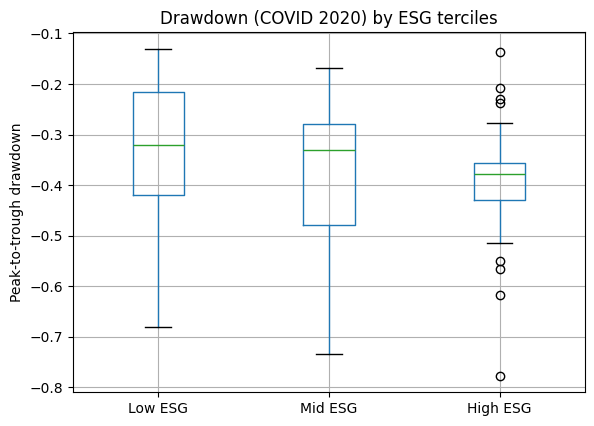

<Figure size 640x480 with 0 Axes>

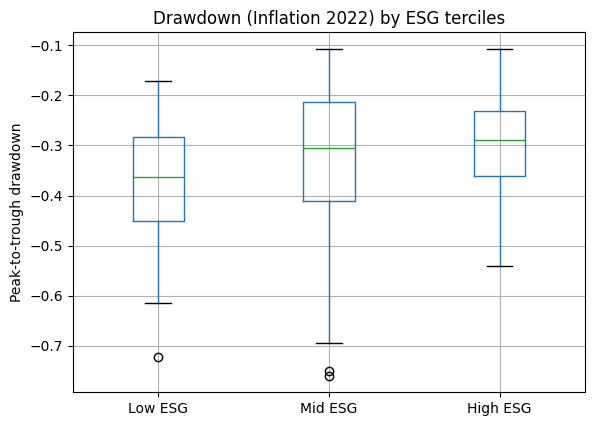

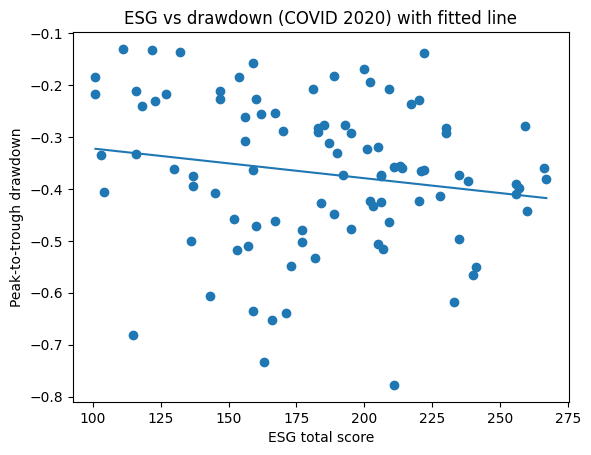

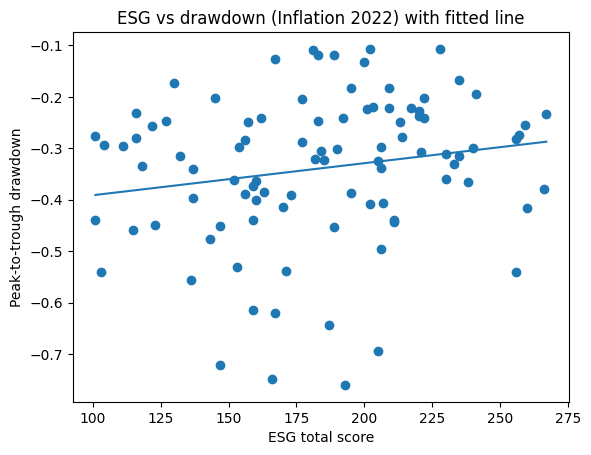

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm


data = analysis_clean.copy()


# Table 1: Descriptive statistics

desc_cols = [c for c in [
    "Drawdown_covid_2020",
    "Drawdown_inflation_2022",
    "ESG_Total", "ESG_E", "ESG_S", "ESG_G",
    "MarketCap", "log_MarketCap",
    "DebtToEquity"
] if c in data.columns]

table1 = data[desc_cols].describe().T
table1["missing"] = data[desc_cols].isna().sum()
table1 = table1[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "missing"]]
print("Table 1: Descriptive statistics")
table1


# Table 2: Correlations

corr_cols = [c for c in [
    "Drawdown_covid_2020",
    "Drawdown_inflation_2022",
    "ESG_Total", "ESG_E", "ESG_S", "ESG_G",
    "log_MarketCap",
    "DebtToEquity"
] if c in data.columns]

table2 = data[corr_cols].corr(numeric_only=True)
print("Table 2: Correlation matrix")
table2


# Table 3: Regression outputs (clean summary table)

def ols_hc1(y_col, x_cols, df):
    w = df[[y_col] + x_cols].dropna().copy()
    y = w[y_col].astype(float)
    X = sm.add_constant(w[x_cols].astype(float))
    return sm.OLS(y, X).fit(cov_type="HC1")

controls_cols = []
if "log_MarketCap" in data.columns:
    controls_cols.append("log_MarketCap")
elif "MarketCap" in data.columns:
    controls_cols.append("MarketCap")
if "DebtToEquity" in data.columns:
    controls_cols.append("DebtToEquity")

models = []
if "Drawdown_covid_2020" in data.columns and "ESG_Total" in data.columns:
    models.append(("COVID 2020", ols_hc1("Drawdown_covid_2020", ["ESG_Total"] + controls_cols, data)))
if "Drawdown_inflation_2022" in data.columns and "ESG_Total" in data.columns:
    models.append(("Inflation 2022", ols_hc1("Drawdown_inflation_2022", ["ESG_Total"] + controls_cols, data)))

rows = []
for name, m in models:
    for var in m.params.index:
        rows.append({
            "Model": name,
            "Variable": var,
            "Coef": m.params[var],
            "SE(HC1)": m.bse[var],
            "t": m.tvalues[var],
            "p": m.pvalues[var],
            "N": int(m.nobs),
            "R2": m.rsquared
        })

table3 = pd.DataFrame(rows)
print("Table 3: Regression results (long format)")
table3


# Figure 1: Distribution of drawdowns by ESG terciles

if "ESG_Total" in data.columns and "Drawdown_covid_2020" in data.columns:
    plot_df = data[["ESG_Total", "Drawdown_covid_2020"]].dropna().copy()
    plot_df["ESG_Tercile"] = pd.qcut(plot_df["ESG_Total"], 3, labels=["Low ESG", "Mid ESG", "High ESG"])

    plt.figure()
    plot_df.boxplot(column="Drawdown_covid_2020", by="ESG_Tercile")
    plt.title("Drawdown (COVID 2020) by ESG terciles")
    plt.suptitle("")
    plt.xlabel("")
    plt.ylabel("Peak-to-trough drawdown")
    plt.show()

if "ESG_Total" in data.columns and "Drawdown_inflation_2022" in data.columns:
    plot_df = data[["ESG_Total", "Drawdown_inflation_2022"]].dropna().copy()
    plot_df["ESG_Tercile"] = pd.qcut(plot_df["ESG_Total"], 3, labels=["Low ESG", "Mid ESG", "High ESG"])

    plt.figure()
    plot_df.boxplot(column="Drawdown_inflation_2022", by="ESG_Tercile")
    plt.title("Drawdown (Inflation 2022) by ESG terciles")
    plt.suptitle("")
    plt.xlabel("")
    plt.ylabel("Peak-to-trough drawdown")
    plt.show()


# Figure 2: Scatter plot ESG vs drawdown with fitted line

def scatter_with_fit(x, y, title, xlab, ylab):
    dfp = data[[x, y]].dropna().copy()
    X = sm.add_constant(dfp[x].astype(float))
    yv = dfp[y].astype(float)
    fit = sm.OLS(yv, X).fit()

    plt.figure()
    plt.scatter(dfp[x], dfp[y])
    xs = np.linspace(dfp[x].min(), dfp[x].max(), 100)
    ys = fit.params["const"] + fit.params[x] * xs
    plt.plot(xs, ys)
    plt.title(title)
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.show()

if "ESG_Total" in data.columns and "Drawdown_covid_2020" in data.columns:
    scatter_with_fit(
        x="ESG_Total",
        y="Drawdown_covid_2020",
        title="ESG vs drawdown (COVID 2020) with fitted line",
        xlab="ESG total score",
        ylab="Peak-to-trough drawdown"
    )

if "ESG_Total" in data.columns and "Drawdown_inflation_2022" in data.columns:
    scatter_with_fit(
        x="ESG_Total",
        y="Drawdown_inflation_2022",
        title="ESG vs drawdown (Inflation 2022) with fitted line",
        xlab="ESG total score",
        ylab="Peak-to-trough drawdown"
    )


In [13]:
import os

BASE_OUT = r"E:\UNIVERSITY OF READING\ICM 406\Python Projects\report_outputs"

FIG_DIR = os.path.join(BASE_OUT, "figures")
TAB_DIR = os.path.join(BASE_OUT, "tables")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

print("Figure folder:", FIG_DIR)
print("Table folder:", TAB_DIR)


Figure folder: E:\UNIVERSITY OF READING\ICM 406\Python Projects\report_outputs\figures
Table folder: E:\UNIVERSITY OF READING\ICM 406\Python Projects\report_outputs\tables


In [3]:
import os
import pandas as pd

base = r"E:\UNIVERSITY OF READING\ICM 406\Python Projects"
prices_path   = os.path.join(base, "prices_long.csv")
controls_path = os.path.join(base, "controls_raw.csv")
esg_path      = os.path.join(base, "esg_raw.csv")

def file_has_data(path):
    return os.path.exists(path) and os.path.getsize(path) > 0

# Load prices
prices = pd.read_csv(prices_path) if file_has_data(prices_path) else pd.DataFrame()
prices.columns = [c.strip() for c in prices.columns]

# Load controls
controls = pd.read_csv(controls_path) if file_has_data(controls_path) else pd.DataFrame()
controls.columns = [c.strip() for c in controls.columns]

# Load ESG
esg = pd.read_csv(esg_path) if file_has_data(esg_path) else pd.DataFrame()
esg.columns = [c.strip() for c in esg.columns]

prices_tickers   = set(prices["Ticker"].astype(str).str.strip().unique()) if "Ticker" in prices.columns else set()
controls_tickers = set(controls["Ticker"].astype(str).str.strip().unique()) if "Ticker" in controls.columns else set()
esg_tickers      = set(esg["Ticker"].astype(str).str.strip().unique()) if "Ticker" in esg.columns else set()

print("Tickers with prices:", len(prices_tickers))
print("Tickers with controls:", len(controls_tickers))
print("Tickers with ESG:", len(esg_tickers))
print("Tickers overlap (prices ∩ controls ∩ ESG):", len(prices_tickers & controls_tickers & esg_tickers))

if "analysis_clean" in globals():
    print("Tickers in final analysis table:", analysis_clean["Ticker"].nunique())
elif "analysis" in globals():
    print("Tickers in final analysis table:", analysis["Ticker"].nunique())
else:
    print("Final analysis table not in memory in this session (analysis_clean / analysis not found).")


Tickers with prices: 200
Tickers with controls: 203
Tickers with ESG: 98
Tickers overlap (prices ∩ controls ∩ ESG): 96
Final analysis table not in memory in this session (analysis_clean / analysis not found).


In [7]:
import os
import numpy as np
import pandas as pd


base = r"E:\UNIVERSITY OF READING\ICM 406\Python Projects"
prices_path   = os.path.join(base, "prices_long.csv")
controls_path = os.path.join(base, "controls_raw.csv")
esg_path      = os.path.join(base, "esg_raw.csv")
analysis_out  = os.path.join(base, "analysis_table.csv")

-
prices = pd.read_csv(prices_path)
controls = pd.read_csv(controls_path)
esg = pd.read_csv(esg_path)

prices.columns = [c.strip() for c in prices.columns]
controls.columns = [c.strip() for c in controls.columns]
esg.columns = [c.strip() for c in esg.columns]

prices["Ticker"] = prices["Ticker"].astype(str).str.strip()
controls["Ticker"] = controls["Ticker"].astype(str).str.strip()
esg["Ticker"] = esg["Ticker"].astype(str).str.strip()

prices["Date"] = pd.to_datetime(prices["Date"], errors="coerce")


EVENT_WINDOWS = {
    "covid_2020":     (pd.Timestamp("2020-02-19"), pd.Timestamp("2020-03-23")),
    "inflation_2022": (pd.Timestamp("2022-01-03"), pd.Timestamp("2022-10-12")),
}

# DRAWDOWN FUNCTION 
def peak_to_trough_drawdown(df_one, start, end):
    d = df_one.loc[(df_one["Date"] >= start) & (df_one["Date"] <= end)].copy()
    if d.empty:
        return np.nan
    if "Adj Close" not in d.columns:
        return np.nan
    d = d.sort_values("Date")
    px = d["Adj Close"].astype(float)
    peak = px.cummax()
    dd = (px / peak) - 1.0
    return float(dd.min())

# COMPUTE DRAWDOWNS
draw_rows = []
for tk, g in prices.groupby("Ticker"):
    row = {"Ticker": tk}
    for k, (st, en) in EVENT_WINDOWS.items():
        row[f"Drawdown_{k}"] = peak_to_trough_drawdown(g, st, en)
    draw_rows.append(row)

drawdowns = pd.DataFrame(draw_rows)



esg_keep = ["Ticker", "ESG_Total", "ESG_E", "ESG_S", "ESG_G"]
esg = esg[[c for c in esg_keep if c in esg.columns]].copy()

controls_keep = ["Ticker", "MarketCap", "DebtToEquity"]
controls = controls[[c for c in controls_keep if c in controls.columns]].copy()


controls["MarketCap"] = pd.to_numeric(controls["MarketCap"], errors="coerce")
controls["log_MarketCap"] = np.where(controls["MarketCap"] > 0, np.log(controls["MarketCap"]), np.nan)


analysis = (
    drawdowns
    .merge(esg, on="Ticker", how="inner")
    .merge(controls, on="Ticker", how="inner")
)

needed = ["Drawdown_covid_2020", "Drawdown_inflation_2022", "ESG_Total", "MarketCap", "DebtToEquity", "log_MarketCap"]
analysis_clean = analysis.dropna(subset=[c for c in needed if c in analysis.columns]).copy()


analysis_clean.to_csv(analysis_out, index=False)

print("Drawdowns rows:", len(drawdowns), "| Unique tickers:", drawdowns["Ticker"].nunique())
print("Analysis rows before drop:", len(analysis))
print("Analysis rows after drop (final):", len(analysis_clean))
print("Saved final analysis table to:", analysis_out)
print("Columns:", list(analysis_clean.columns))
analysis_clean.head()


Drawdowns rows: 200 | Unique tickers: 200
Analysis rows before drop: 96
Analysis rows after drop (final): 84
Saved final analysis table to: E:\UNIVERSITY OF READING\ICM 406\Python Projects\analysis_table.csv
Columns: ['Ticker', 'Drawdown_covid_2020', 'Drawdown_inflation_2022', 'ESG_Total', 'ESG_E', 'ESG_S', 'ESG_G', 'MarketCap', 'DebtToEquity', 'log_MarketCap']


,Ticker,Drawdown_covid_2020,Drawdown_inflation_2022,ESG_Total,ESG_E,ESG_S,ESG_G,MarketCap,DebtToEquity,log_MarketCap
0,AAPL,-0.306687,-0.283462,156,63,73,20,3.716844e+12,152.411,28.943896
1,AEP,-0.323671,-0.222856,201,59,72,70,6.403917e+10,152.132,24.882761
2,ALL,-0.407762,-0.203090,145,96,20,29,5.133479e+10,29.430,24.661635
3,AMGN,-0.182634,-0.118978,189,92,56,41,1.771171e+11,567.491,25.900077
4,AMZN,-0.227447,-0.399605,160,90,50,20,2.505573e+12,43.405,28.549539


In [5]:
import os
import pandas as pd
import statsmodels.api as sm

base = r"E:\UNIVERSITY OF READING\ICM 406\Python Projects"
analysis_path = os.path.join(base, "analysis_table.csv")
out_xlsx      = os.path.join(base, "ols_tables.xlsx")

df = pd.read_csv(analysis_path)

def run_ols(dep, indep_cols, data):
    X = data[indep_cols].copy()
    X = sm.add_constant(X)
    y = data[dep]
    m = sm.OLS(y, X, missing="drop").fit(cov_type="HC1")
    tab = pd.DataFrame({
        "variable": m.params.index,
        "coef": m.params.values,
        "std_err_HC1": m.bse.values,
        "t_or_z": m.tvalues.values,
        "p_value": m.pvalues.values,
    })
    
    tab["N"] = int(m.nobs)
    tab["R2"] = float(m.rsquared)
    tab["Adj_R2"] = float(m.rsquared_adj)
    return m, tab

controls = ["ESG_Total", "log_MarketCap", "DebtToEquity"]

m_covid, tab_covid = run_ols("Drawdown_covid_2020", controls, df)
m_infl,  tab_infl  = run_ols("Drawdown_inflation_2022", controls, df)

with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
    tab_covid.to_excel(writer, sheet_name="Model_A_COVID2020", index=False)
    tab_infl.to_excel(writer, sheet_name="Model_B_INFL2022", index=False)
    df.to_excel(writer, sheet_name="analysis_table_used", index=False)

print("Saved Excel OLS tables to:", out_xlsx)
print("COVID model N:", int(m_covid.nobs), "R2:", round(m_covid.rsquared, 4))
print("Inflation model N:", int(m_infl.nobs), "R2:", round(m_infl.rsquared, 4))


Saved Excel OLS tables to: E:\UNIVERSITY OF READING\ICM 406\Python Projects\ols_tables.xlsx
COVID model N: 84 R2: 0.0953
Inflation model N: 84 R2: 0.0589


In [8]:
!pip install -U openpyxl

  Attempting uninstall: openpyxl
    Found existing installation: openpyxl 3.0.10
    Uninstalling openpyxl-3.0.10:
      Successfully uninstalled openpyxl-3.0.10


  You can safely remove it manually.
ERROR: Exception:
Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\Lib\site-packages\pip\_internal\metadata\importlib\_dists.py", line 174, in version
    return parse_version(version)
           ^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\site-packages\pip\_vendor\packaging\version.py", line 56, in parse
    return Version(version)
           ^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\site-packages\pip\_vendor\packaging\version.py", line 200, in __init__
    match = self._regex.search(version)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: expected string or bytes-like object, got 'NoneType'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\Lib\site-packages\pip\_internal\cli\base_command.py", line 107, in _run_wrapper
    status = _inner_run()
             ^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\site-p

In [1]:
import openpyxl
openpyxl.__version__

'3.1.5'

In [2]:
import os
import pandas as pd

base = r"E:\UNIVERSITY OF READING\ICM 406\Python Projects"
xls_path = os.path.join(base, "ols_tables.xlsx")   # change if your file name is different

cov  = pd.read_excel(xls_path, sheet_name="Model_A_COVID2020")
infl = pd.read_excel(xls_path, sheet_name="Model_B_INFL2022")


for df in (cov, infl):
    df.columns = [c.strip() for c in df.columns]
    df["variable"] = df["variable"].astype(str).str.strip()


cov_s = cov[["variable","coef","std_err_HC1","t_or_z","p_value","N","R2","Adj_R2"]].copy()
cov_s = cov_s.rename(columns={
    "coef":"coef_COVID", "std_err_HC1":"se_COVID", "t_or_z":"t_COVID", "p_value":"p_COVID",
    "N":"N_COVID", "R2":"R2_COVID", "Adj_R2":"AdjR2_COVID"
})

infl_s = infl[["variable","coef","std_err_HC1","t_or_z","p_value","N","R2","Adj_R2"]].copy()
infl_s = infl_s.rename(columns={
    "coef":"coef_INFL", "std_err_HC1":"se_INFL", "t_or_z":"t_INFL", "p_value":"p_INFL",
    "N":"N_INFL", "R2":"R2_INFL", "Adj_R2":"AdjR2_INFL"
})


tab = pd.merge(cov_s, infl_s, on="variable", how="outer")


order = ["const", "ESG_Total", "log_MarketCap", "DebtToEquity"]
tab["__order__"] = tab["variable"].map({v:i for i,v in enumerate(order)}).fillna(999)
tab = tab.sort_values("__order__").drop(columns="__order__").reset_index(drop=True)


with pd.ExcelWriter(xls_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    tab.to_excel(writer, sheet_name="Table_regressions", index=False)

print("Done. Created/updated sheet: Table_regressions")
print("Saved to:", xls_path)


Done. Created/updated sheet: Table_regressions
Saved to: E:\UNIVERSITY OF READING\ICM 406\Python Projects\ols_tables.xlsx


In [5]:
import os
import pandas as pd

base = r"E:\UNIVERSITY OF READING\ICM 406\Python Projects"
xls_path = os.path.join(base, "ols_tables.xlsx")


xl = pd.ExcelFile(xls_path)
sheets = xl.sheet_names
print("Sheets:", sheets)


cov_sheet  = next((s for s in sheets if "cov" in s.lower()), None)
infl_sheet = next((s for s in sheets if "infl" in s.lower()), None)

if cov_sheet is None or infl_sheet is None:
    raise ValueError("Could not auto-detect COVID/INFL sheets. Rename sheets to include 'COVID' and 'INFL' or paste sheet names here.")

cov  = pd.read_excel(xls_path, sheet_name=cov_sheet)
infl = pd.read_excel(xls_path, sheet_name=infl_sheet)


def clean_cols(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df

cov  = clean_cols(cov)
infl = clean_cols(infl)


req = ["variable","coef","std_err_HC1","t_or_z","p_value","N","R2","Adj_R2"]
missing_cov  = [c for c in req if c not in cov.columns]
missing_infl = [c for c in req if c not in infl.columns]
if missing_cov or missing_infl:
    raise KeyError(f"Missing columns. COVID missing={missing_cov}, INFL missing={missing_infl}")


cov2 = cov.rename(columns={
    "coef":"coef_COVID","std_err_HC1":"se_COVID","t_or_z":"t_COVID","p_value":"p_COVID",
    "N":"N_COVID","R2":"R2_COVID","Adj_R2":"AdjR2_COVID"
})
infl2 = infl.rename(columns={
    "coef":"coef_INFL","std_err_HC1":"se_INFL","t_or_z":"t_INFL","p_value":"p_INFL",
    "N":"N_INFL","R2":"R2_INFL","Adj_R2":"AdjR2_INFL"
})


df = pd.merge(cov2[["variable","coef_COVID","se_COVID","p_COVID","N_COVID","R2_COVID","AdjR2_COVID"]],
              infl2[["variable","coef_INFL","se_INFL","p_INFL","N_INFL","R2_INFL","AdjR2_INFL"]],
              on="variable", how="outer")


def stars(p):
    if pd.isna(p): return ""
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

def fmt(coef, se, p):
    if pd.isna(coef): return ""
    return f"{coef:.5f}{stars(p)} ({se:.5f})"

table3 = pd.DataFrame({
    "Variable": df["variable"],
    "COVID 2020 (coef (HC1 se))": [fmt(c,s,p) for c,s,p in zip(df["coef_COVID"], df["se_COVID"], df["p_COVID"])],
    "Inflation 2022 (coef (HC1 se))": [fmt(c,s,p) for c,s,p in zip(df["coef_INFL"], df["se_INFL"], df["p_INFL"])],
})


stats = pd.DataFrame({
    "Variable": ["N", "R-squared", "Adj. R-squared"],
    "COVID 2020 (coef (HC1 se))": [
        int(pd.Series(df["N_COVID"]).dropna().iloc[0]),
        float(pd.Series(df["R2_COVID"]).dropna().iloc[0]),
        float(pd.Series(df["AdjR2_COVID"]).dropna().iloc[0]),
    ],
    "Inflation 2022 (coef (HC1 se))": [
        int(pd.Series(df["N_INFL"]).dropna().iloc[0]),
        float(pd.Series(df["R2_INFL"]).dropna().iloc[0]),
        float(pd.Series(df["AdjR2_INFL"]).dropna().iloc[0]),
    ],
})

table3_out = pd.concat([table3, pd.DataFrame([{"Variable": ""}]), stats], ignore_index=True)

out_xlsx = os.path.join(base, "Table3_Regressions.xlsx")
out_csv  = os.path.join(base, "Table3_Regressions.csv")

with pd.ExcelWriter(out_xlsx) as writer:
    table3_out.to_excel(writer, sheet_name="Table3", index=False)

table3_out.to_csv(out_csv, index=False)

print("Saved:", out_xlsx)
print("Saved:", out_csv)
table3_out.head(10)

Sheets: ['Model_A_COVID2020', 'Model_B_INFL2022', 'analysis_table_used', 'Table_regressions']
Saved: E:\UNIVERSITY OF READING\ICM 406\Python Projects\Table3_Regressions.xlsx
Saved: E:\UNIVERSITY OF READING\ICM 406\Python Projects\Table3_Regressions.csv


,Variable,COVID 2020 (coef (HC1 se)),Inflation 2022 (coef (HC1 se))
0,DebtToEquity,-0.00003 (0.00006),0.00007 (0.00005)
1,ESG_Total,-0.00071** (0.00031),0.00056* (0.00031)
2,const,-0.84492** (0.34274),-0.97560*** (0.36727)
3,log_MarketCap,0.02448* (0.01342),0.02055 (0.01402)
4,,NaN,NaN
5,N,84.0,84.0
6,R-squared,0.095273,0.05892
7,Adj. R-squared,0.061346,0.02363


In [2]:
import os
import pandas as pd

base = r"E:\UNIVERSITY OF READING\ICM 406\Python Projects"


candidates = ["analysis_clean.csv", "analysis_table.csv", "analysis_table_clean.csv"]

analysis_clean = None
for fn in candidates:
    p = os.path.join(base, fn)
    if os.path.exists(p) and os.path.getsize(p) > 0:
        analysis_clean = pd.read_csv(p)
        print("Loaded:", p)
        break

if analysis_clean is None:
    raise FileNotFoundError("Could not find a saved final analysis table in the base folder.")

analysis_clean.columns = [c.strip() for c in analysis_clean.columns]
analysis_clean["Ticker"] = analysis_clean["Ticker"].astype(str).str.strip()

print("Rows:", len(analysis_clean))
print("Unique tickers:", analysis_clean["Ticker"].nunique())
print("Columns:", list(analysis_clean.columns))
analysis_clean.head()


Loaded: E:\UNIVERSITY OF READING\ICM 406\Python Projects\analysis_table.csv
Rows: 84
Unique tickers: 84
Columns: ['Ticker', 'Drawdown_covid_2020', 'Drawdown_inflation_2022', 'ESG_Total', 'ESG_E', 'ESG_S', 'ESG_G', 'MarketCap', 'DebtToEquity', 'log_MarketCap']


,Ticker,Drawdown_covid_2020,Drawdown_inflation_2022,ESG_Total,ESG_E,ESG_S,ESG_G,MarketCap,DebtToEquity,log_MarketCap
0,AAPL,-0.306687,-0.283462,156,63,73,20,3.716844e+12,152.411,28.943896
1,AEP,-0.323671,-0.222856,201,59,72,70,6.403917e+10,152.132,24.882761
2,ALL,-0.407762,-0.203090,145,96,20,29,5.133479e+10,29.430,24.661635
3,AMGN,-0.182634,-0.118978,189,92,56,41,1.771171e+11,567.491,25.900077
4,AMZN,-0.227447,-0.399605,160,90,50,20,2.505573e+12,43.405,28.549539


In [12]:
%pip install -q XlsxWriter

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm

base = r"E:\UNIVERSITY OF READING\ICM 406\Python Projects"
out_xlsx = os.path.join(base, "Table3_Regressions.xlsx")

df = analysis_clean.copy()

-
X_cols = ["ESG_Total", "log_MarketCap", "DebtToEquity"]
models = [
    ("COVID 2020", "Drawdown_covid_2020"),
    ("Inflation 2022", "Drawdown_inflation_2022"),
]

def stars(p):
    if pd.isna(p): 
        return ""
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

def fmt_coef_se(coef, se, p):
    if pd.isna(coef) or pd.isna(se):
        return ""
    return f"{coef:.5f}{stars(p)} ({se:.5f})"

results_blocks = {}

for label, y_col in models:
    d = df[["Ticker", y_col] + X_cols].dropna().copy()
    y = d[y_col]
    X = sm.add_constant(d[X_cols], has_constant="add")
    m = sm.OLS(y, X).fit(cov_type="HC1")
    
    tmp = pd.DataFrame({
        "variable": m.params.index,
        f"coef_{label}": m.params.values,
        f"se_{label}": m.bse.values,
        f"p_{label}": m.pvalues.values
    })
    results_blocks[label] = {
        "table": tmp,
        "N": int(m.nobs),
        "R2": float(m.rsquared),
        "AdjR2": float(m.rsquared_adj)
    }

# Merge the two model coefficient tables
cov_tbl = results_blocks["COVID 2020"]["table"]
inf_tbl = results_blocks["Inflation 2022"]["table"]

merged = cov_tbl.merge(inf_tbl, on="variable", how="outer")


order = ["ESG_Total", "log_MarketCap", "DebtToEquity", "const"]
merged["order"] = merged["variable"].apply(lambda x: order.index(x) if x in order else 999)
merged = merged.sort_values("order").drop(columns=["order"]).reset_index(drop=True)


table3 = pd.DataFrame({
    "Variable": merged["variable"],
    "COVID 2020 (coef (HC1 se))": [
        fmt_coef_se(c, s, p) for c, s, p in zip(
            merged["coef_COVID 2020"], merged["se_COVID 2020"], merged["p_COVID 2020"]
        )
    ],
    "Inflation 2022 (coef (HC1 se))": [
        fmt_coef_se(c, s, p) for c, s, p in zip(
            merged["coef_Inflation 2022"], merged["se_Inflation 2022"], merged["p_Inflation 2022"]
        )
    ],
})


stats = pd.DataFrame({
    "Variable": ["N", "R-squared", "Adj. R-squared"],
    "COVID 2020 (coef (HC1 se))": [
        results_blocks["COVID 2020"]["N"],
        results_blocks["COVID 2020"]["R2"],
        results_blocks["COVID 2020"]["AdjR2"],
    ],
    "Inflation 2022 (coef (HC1 se))": [
        results_blocks["Inflation 2022"]["N"],
        results_blocks["Inflation 2022"]["R2"],
        results_blocks["Inflation 2022"]["AdjR2"],
    ],
})

final_table = pd.concat([table3, pd.DataFrame([["", "", ""]], columns=table3.columns), stats], ignore_index=True)

with pd.ExcelWriter(out_xlsx, engine="xlsxwriter") as writer:
    final_table.to_excel(writer, sheet_name="Table3_Regressions", index=False)
    df.to_excel(writer, sheet_name="analysis_table_used", index=False)

print("Saved:", out_xlsx)
final_table


Saved: E:\UNIVERSITY OF READING\ICM 406\Python Projects\Table3_Regressions.xlsx


,Variable,COVID 2020 (coef (HC1 se)),Inflation 2022 (coef (HC1 se))
0,ESG_Total,-0.00071** (0.00031),0.00056* (0.00031)
1,log_MarketCap,0.02448* (0.01342),0.02055 (0.01402)
2,DebtToEquity,-0.00003 (0.00006),0.00007 (0.00005)
3,const,-0.84492** (0.34274),-0.97560*** (0.36727)
4,,,
5,N,84.0,84.0
6,R-squared,0.095273,0.05892
7,Adj. R-squared,0.061346,0.02363


In [4]:
import pandas as pd, os

base = r"E:\UNIVERSITY OF READING\ICM 406\Python Projects"
prices = pd.read_csv(os.path.join(base, "prices_long.csv"))
prices["Date"] = pd.to_datetime(prices["Date"])
print("Start:", prices["Date"].min())
print("End:", prices["Date"].max())
print("Unique years:", sorted(prices["Date"].dt.year.unique()))


Start: 2020-01-02 00:00:00
End: 2024-12-30 00:00:00
Unique years: [2020, 2021, 2022, 2023, 2024]


Saved correlation matrix to: E:\UNIVERSITY OF READING\ICM 406\Python Projects\correlation_matrix.csv
Saved correlation map to: E:\UNIVERSITY OF READING\ICM 406\Python Projects\Figure_CorrelationMap.png


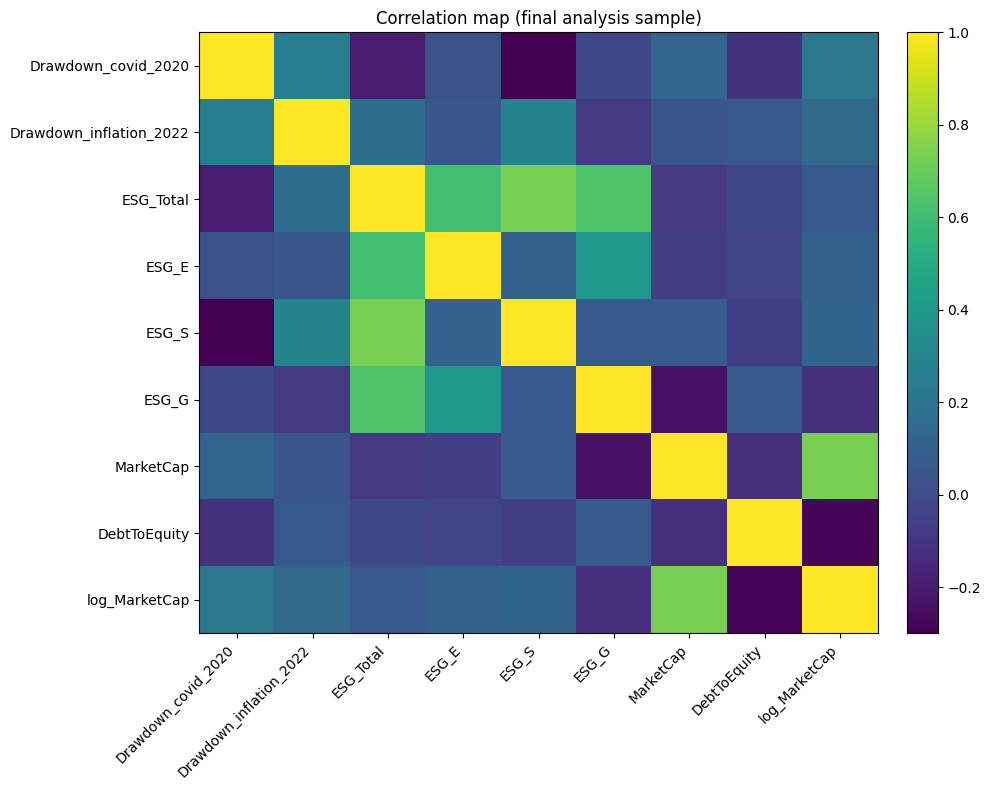

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Correlation Matrix
base = r"E:\UNIVERSITY OF READING\ICM 406\Python Projects"
analysis_path = os.path.join(base, "analysis_table.csv")


df = pd.read_csv(analysis_path)


num = df.select_dtypes(include="number").copy()


corr = num.corr(method="pearson")


corr_csv = os.path.join(base, "correlation_matrix.csv")
corr.to_csv(corr_csv, index=True)
print("Saved correlation matrix to:", corr_csv)


plt.figure(figsize=(10, 8))
im = plt.imshow(corr.values, aspect="auto")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("Correlation map (final analysis sample)")

plt.tight_layout()


out_png = os.path.join(base, "Figure_CorrelationMap.png")
plt.savefig(out_png, dpi=300, bbox_inches="tight")
print("Saved correlation map to:", out_png)

plt.show()


In [6]:

import os
import numpy as np
import pandas as pd

import statsmodels.api as sm
import matplotlib.pyplot as plt

base = r"E:\UNIVERSITY OF READING\ICM 406\Python Projects"

prices_path  = os.path.join(base, "prices_long.csv")
analysis_path = os.path.join(base, "analysis_table.csv")  # your final 84-firm table

out_beta_csv = os.path.join(base, "rolling_esg_beta_60_monthend.csv")
out_fig_png  = os.path.join(base, "rolling_esg_beta_60_monthend.png")

def file_has_data(path):
    return os.path.exists(path) and os.path.getsize(path) > 0

if not file_has_data(prices_path):
    raise FileNotFoundError(f"Missing or empty: {prices_path}")

if not file_has_data(analysis_path):
    raise FileNotFoundError(f"Missing or empty: {analysis_path}")

prices = pd.read_csv(prices_path)
analysis = pd.read_csv(analysis_path)


prices.columns = [c.strip() for c in prices.columns]
analysis.columns = [c.strip() for c in analysis.columns]


if "Date" not in prices.columns:
    raise KeyError("prices_long.csv must contain a Date column.")
prices["Date"] = pd.to_datetime(prices["Date"], errors="coerce")
prices = prices.dropna(subset=["Date"]).copy()


price_col = None
for c in ["Adj Close", "Adj_Close", "AdjClose", "Close"]:
    if c in prices.columns:
        price_col = c
        break
if price_col is None:
    raise KeyError("prices_long.csv must contain one of: Adj Close, Adj_Close, AdjClose, Close")


if "Ticker" not in prices.columns:
    raise KeyError("prices_long.csv must contain a Ticker column.")
prices["Ticker"] = prices["Ticker"].astype(str).str.strip()


START = pd.Timestamp("2020-01-01")
END   = pd.Timestamp("2024-12-31")
prices = prices[(prices["Date"] >= START) & (prices["Date"] <= END)].copy()

print("Loaded prices rows:", len(prices))
print("Loaded analysis rows:", len(analysis))
print("Price tickers:", prices["Ticker"].nunique(), "| Analysis tickers:", analysis["Ticker"].nunique())
print("Price column used:", price_col)


Loaded prices rows: 248871
Loaded analysis rows: 84
Price tickers: 200 | Analysis tickers: 84
Price column used: Adj Close


In [7]:

# Rolling max drawdown (60 trading days) per ticker

WINDOW = 60

def rolling_mdd(arr: np.ndarray) -> float:
    # arr is a 1D window of prices
    running_max = np.maximum.accumulate(arr)
    dd = arr / running_max - 1.0
    return float(np.min(dd))

prices = prices.sort_values(["Ticker", "Date"]).copy()

# Rolling MDD on prices
roll = (
    prices.groupby("Ticker", group_keys=False)[price_col]
    .apply(lambda s: s.rolling(WINDOW, min_periods=WINDOW).apply(rolling_mdd, raw=True))
)

prices[f"Rolling_MDD_{WINDOW}"] = roll.values


prices_roll = prices.dropna(subset=[f"Rolling_MDD_{WINDOW}"]).copy()

print("Rows after rolling window available:", len(prices_roll))
print("Tickers with rolling MDD:", prices_roll["Ticker"].nunique())
prices_roll.head()


Rows after rolling window available: 237071
Tickers with rolling MDD: 200


,Date,Ticker,Adj Close,Close,High,Low,Open,Volume,Rolling_MDD_60
59,2020-03-27,AAL,14.04,14.04,15.22,13.91,14.98,50783500.0,-0.663604
60,2020-03-30,AAL,12.25,12.25,13.22,11.81,13.20,50516800.0,-0.663604
61,2020-03-31,AAL,12.19,12.19,12.96,12.10,12.90,44851400.0,-0.663604
62,2020-04-01,AAL,10.69,10.69,11.48,10.50,11.45,56854400.0,-0.663604
63,2020-04-02,AAL,10.06,10.06,11.03,10.00,10.61,65534600.0,-0.669839


In [8]:

# Cell 3: Keep month-end observations only (per ticker)

mdd_col = f"Rolling_MDD_{WINDOW}"

prices_roll["Month"] = prices_roll["Date"].dt.to_period("M")


month_end = (
    prices_roll.sort_values(["Ticker", "Date"])
    .groupby(["Ticker", "Month"], as_index=False)
    .tail(1)
    .copy()
)

print("Month-end rows:", len(month_end))
print("Unique months:", month_end["Month"].nunique())
month_end[["Ticker", "Date", mdd_col]].head()


Month-end rows: 11475
Unique months: 58


,Ticker,Date,Rolling_MDD_60
61,AAL,2020-03-31,-0.663604
82,AAL,2020-04-30,-0.691828
102,AAL,2020-05-29,-0.468235
124,AAL,2020-06-30,-0.390448
146,AAL,2020-07-31,-0.452486


In [9]:

# Merge static firm data (ESG + controls) from analysis_table.csv

needed_cols = ["Ticker", "ESG_Total", "log_MarketCap", "DebtToEquity"]
missing_cols = [c for c in needed_cols if c not in analysis.columns]
if missing_cols:
    raise KeyError(f"analysis_table.csv is missing columns: {missing_cols}")

firm = analysis[needed_cols].copy()
firm["Ticker"] = firm["Ticker"].astype(str).str.strip()

panel = month_end.merge(firm, on="Ticker", how="inner")

print("Panel rows after merge:", len(panel))
print("Panel tickers:", panel["Ticker"].nunique())
print("Panel months:", panel["Month"].nunique())
panel.head()


Panel rows after merge: 4872
Panel tickers: 84
Panel months: 58


,Date,Ticker,Adj Close,Close,High,Low,Open,Volume,Rolling_MDD_60,Month,ESG_Total,log_MarketCap,DebtToEquity
0,2020-03-31,AAPL,61.500538,63.572498,65.622498,63.000000,63.900002,197002000.0,-0.314273,2020-03,156,28.943896,152.411
1,2020-04-30,AAPL,71.056114,73.449997,73.632500,72.087502,72.489998,183064000.0,-0.314273,2020-04,156,28.943896,152.411
2,2020-05-29,AAPL,77.102592,79.485001,80.287498,79.117500,79.812500,153532400.0,-0.234023,2020-05,156,28.943896,152.411
3,2020-06-30,AAPL,88.466431,91.199997,91.495003,90.000000,90.019997,140223200.0,-0.065076,2020-06,156,28.943896,152.411
4,2020-07-31,AAPL,103.075058,106.260002,106.415001,100.824997,102.885002,374336800.0,-0.058384,2020-07,156,28.943896,152.411


In [10]:

#  Monthly cross-sectional regressions (HC1), store ESG beta

MIN_N = 70
X_cols = ["ESG_Total", "log_MarketCap", "DebtToEquity"]

rows = []
for month, g in panel.groupby("Month"):
    d = g.dropna(subset=[mdd_col] + X_cols).copy()
    N = len(d)
    if N < MIN_N:
        continue

    y = d[mdd_col].astype(float)
    X = sm.add_constant(d[X_cols].astype(float), has_constant="add")

    model = sm.OLS(y, X).fit(cov_type="HC1")

    b = float(model.params.get("ESG_Total", np.nan))
    se = float(model.bse.get("ESG_Total", np.nan))

    rows.append({
        "Month": str(month),
        "Date": pd.Period(month, freq="M").to_timestamp("M"),
        "N": int(model.nobs),
        "beta_ESG_Total": b,
        "se_ESG_Total_HC1": se,
        "ci_low_95": b - 1.96 * se,
        "ci_high_95": b + 1.96 * se,
        "R2": float(model.rsquared),
        "Adj_R2": float(model.rsquared_adj),
    })

betas = pd.DataFrame(rows).sort_values("Date").reset_index(drop=True)

if len(betas) == 0:
    raise ValueError("No months met MIN_N. Lower MIN_N or check missing data.")

betas.to_csv(out_beta_csv, index=False)
print("Saved rolling beta table to:", out_beta_csv)
betas.head()


Saved rolling beta table to: E:\UNIVERSITY OF READING\ICM 406\Python Projects\rolling_esg_beta_60_monthend.csv


,Month,Date,N,beta_ESG_Total,se_ESG_Total_HC1,ci_low_95,ci_high_95,R2,Adj_R2
0,2020-03,2020-03-31,84,-0.000571,0.000320,-0.001198,0.000056,0.093951,0.059974
1,2020-04,2020-04-30,84,-0.000660,0.000310,-0.001268,-0.000052,0.101782,0.068099
2,2020-05,2020-05-31,84,-0.000484,0.000265,-0.001003,0.000035,0.135878,0.103473
3,2020-06,2020-06-30,84,-0.000037,0.000148,-0.000327,0.000252,0.095600,0.061685
4,2020-07,2020-07-31,84,0.000093,0.000179,-0.000257,0.000443,0.116221,0.083080


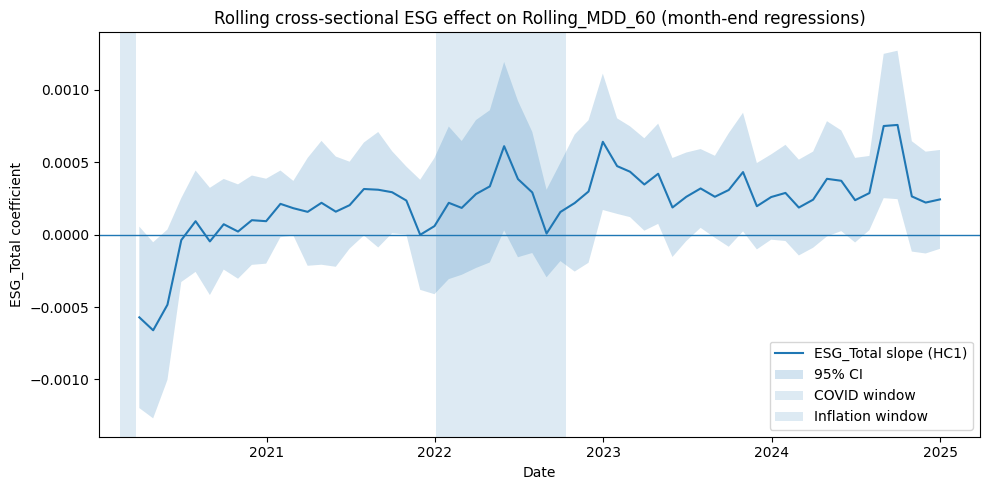

Saved figure to: E:\UNIVERSITY OF READING\ICM 406\Python Projects\rolling_esg_beta_60_monthend.png


In [11]:

# Ploting ESG beta over time + event window markers, save PNG

betas["Date"] = pd.to_datetime(betas["Date"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(betas["Date"], betas["beta_ESG_Total"], label="ESG_Total slope (HC1)")
ax.fill_between(betas["Date"], betas["ci_low_95"], betas["ci_high_95"], alpha=0.2, label="95% CI")

# Event windows (your fixed definitions)
covid_start = pd.Timestamp("2020-02-19")
covid_end   = pd.Timestamp("2020-03-23")
infl_start  = pd.Timestamp("2022-01-03")
infl_end    = pd.Timestamp("2022-10-12")

ax.axvspan(covid_start, covid_end, alpha=0.15, label="COVID window")
ax.axvspan(infl_start, infl_end, alpha=0.15, label="Inflation window")

ax.axhline(0.0, linewidth=1)
ax.set_title(f"Rolling cross-sectional ESG effect on {mdd_col} (month-end regressions)")
ax.set_xlabel("Date")
ax.set_ylabel("ESG_Total coefficient")
ax.legend()
plt.tight_layout()

fig.savefig(out_fig_png, dpi=200)
plt.show()

print("Saved figure to:", out_fig_png)


In [1]:
import os
import pandas as pd
import statsmodels.api as sm

base = r"E:\UNIVERSITY OF READING\ICM 406\Python Projects"
out_xlsx = os.path.join(base, "Table4_Pillar_Regressions.xlsx")


if "analysis" in globals():
    df = analysis.copy()
elif "analysis_clean" in globals():
    df = analysis_clean.copy()
else:
    df = pd.read_csv(os.path.join(base, "analysis_table.csv"))

X_controls = ["log_MarketCap", "DebtToEquity"]
pillars = ["ESG_E", "ESG_S", "ESG_G"]
events = [
    ("COVID 2020", "Drawdown_covid_2020"),
    ("Inflation 2022", "Drawdown_inflation_2022"),
]

def stars(p):
    if pd.isna(p): return ""
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

def fmt(coef, se, p):
    if pd.isna(coef) or pd.isna(se): 
        return ""
    return f"{coef:.5f}{stars(p)} ({se:.5f})"

all_tables = {}

for event_label, y_col in events:
    rows = []
    stats_rows = []
    for p in pillars:
        d = df[[y_col, p] + X_controls].dropna().copy()
        y = d[y_col]
        X = sm.add_constant(d[[p] + X_controls], has_constant="add")
        m = sm.OLS(y, X).fit(cov_type="HC1")

        tmp = pd.DataFrame({
            "variable": m.params.index,
            "coef": m.params.values,
            "se_HC1": m.bse.values,
            "p_value": m.pvalues.values
        })
        tmp["formatted"] = [fmt(c, s, pv) for c, s, pv in zip(tmp["coef"], tmp["se_HC1"], tmp["p_value"])]

        # Keep a clean, Word-ready table
        wide = tmp.set_index("variable")["formatted"].rename(p).to_frame()
        rows.append(wide)

        stats_rows.append(pd.Series({
            "N": int(m.nobs),
            "R-squared": float(m.rsquared),
            "Adj. R-squared": float(m.rsquared_adj)
        }, name=p))

    
    reg_table = pd.concat(rows, axis=1).reset_index().rename(columns={"index": "Variable"})
    stat_table = pd.DataFrame(stats_rows)

    all_tables[event_label] = (reg_table, stat_table)

with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
    for event_label, (reg_table, stat_table) in all_tables.items():
        reg_table.to_excel(writer, sheet_name=f"{event_label}_Pillars", index=False)
        stat_table.to_excel(writer, sheet_name=f"{event_label}_Stats", index=True)
    df.to_excel(writer, sheet_name="analysis_table_used", index=False)

print("Saved:", out_xlsx)


Saved: E:\UNIVERSITY OF READING\ICM 406\Python Projects\Table4_Pillar_Regressions.xlsx
